# Voxel Allegiance — Cross-Sectional Group-Level (Liu-Aligned)

Group-level patient vs control comparisons of full-VOTC WTA maps using
Liu contrasts and MNI zstats. Tests how voxel allegiance differs between
groups beyond peak displacement and sum-selectivity.

**Sample (cross-sectional):**
- Controls (n≈38): both hemispheres
- OTC patients only (nonOTC excluded), intact hemisphere
- One session per subject (first available post-surgery)

**Analyses (group-level perm tests, 10k permutations, seed 42):**
1. WTA territory % per category × hemisphere
2. Pairwise category neighborhood (boundary preservation)
3. Control-defined territory displacement (where does territory go in patients?)
4. WTA margin distributions per category × hemisphere

**Pipeline alignment:**
- Liu contrasts: cope 1=Face>Object, 2=House>Object, 3=Object>Scramble, −cope 13=Word>Face
- Pre-registered MNI zstats from `13_register_zstats_mni.py`
- WTA threshold z > 2.326
- VOTC mask: Harvard-Oxford labels (MNI 2mm)

## Setup

In [1]:
import os, sys
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

from nilearn import datasets as nl_datasets

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#E74C3C', 'house': '#3498DB',
              'object': '#2ECC71', 'word': '#F39C12'}

LIU_CONTRASTS = {
    'face':   (1,  False),
    'house':  (2,  False),
    'object': (3,  False),
    'word':   (13, True),
}

WTA_THRESHOLD = 2.326
N_PERM = 10000
RNG_SEED = 42

EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

OUT_DIR = os.path.join(processed_dir, 'group_results', 'voxel_allegiance_liu')
FIG_DIR = os.path.join(OUT_DIR, 'figures_xs')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Output: {FIG_DIR}')
print(f'WTA threshold: z > {WTA_THRESHOLD}')
print(f'Permutations: {N_PERM} (seed {RNG_SEED})')

Output: /user_data/csimmon2/sym_pt/group_results/voxel_allegiance_liu/figures_xs
WTA threshold: z > 2.326
Permutations: 10000 (seed 42)


## Helpers — VOTC mask, loaders

In [2]:
# VOTC mask (Harvard-Oxford), hemisphere-split
ho_atlas = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho_atlas.maps if isinstance(ho_atlas.maps, nib.Nifti1Image) else nib.load(ho_atlas.maps)
ho_data = ho_img.get_fdata()
ho_labels = ho_atlas.labels

VOTC_LABEL_NAMES = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Temporal Occipital Fusiform Cortex',
    'Parahippocampal Gyrus, anterior division',
    'Parahippocampal Gyrus, posterior division',
    'Lingual Gyrus',
    'Lateral Occipital Cortex, superior division',
    'Lateral Occipital Cortex, inferior division',
]

_votc_full = np.zeros(ho_data.shape, dtype=bool)
for name in VOTC_LABEL_NAMES:
    matches = [i for i, l in enumerate(ho_labels) if name in l]
    if matches:
        _votc_full |= (ho_data == matches[0])

mid_x = ho_data.shape[0] // 2
VOTC_MASK_LH = _votc_full.copy(); VOTC_MASK_LH[:mid_x] = False
VOTC_MASK_RH = _votc_full.copy(); VOTC_MASK_RH[mid_x:] = False
MNI_AFFINE = ho_img.affine
MNI_SHAPE  = ho_data.shape

print(f'LH VOTC: {VOTC_MASK_LH.sum():,} voxels')
print(f'RH VOTC: {VOTC_MASK_RH.sum():,} voxels')


def get_votc_mask(hemi):
    return VOTC_MASK_LH if hemi == 'l' else VOTC_MASK_RH


# ── Subject loader: cross-sectional, OTC only (no nonOTC) ─────────────
def load_subjects_xs():
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs:
            continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        if not sessions or not os.path.exists(os.path.join(processed_dir, sid)):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        group = info.get('group', 'unknown')
        code_str = f"{group}{sc}"
        if code_str in EXTRA_SKIP or sid in EXTRA_SKIP:
            continue

        # CRITICAL: drop nonOTC
        if group == 'nonOTC':
            continue

        # Pick first post-surgery session
        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if ses_str in PRE_SURGERY_SESSIONS.get(sid, set()):
                continue
            post_sessions.append(ses_str)
        if not post_sessions:
            continue

        subjects[sid] = {
            'session': post_sessions[0],
            'group': group,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


# ── MNI zstat loader ─────────────────────────────────────────────────
def get_mni_zstat_path(sub_id, session, cope_num):
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    return os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats',
                        'zstat1_mni.nii.gz')


def load_category_zstats_3d(sub_id, session):
    """Load 4 Liu-contrast zstats as full 3D volumes (negate word)."""
    vols = {}
    for cat, (cope_num, negate) in LIU_CONTRASTS.items():
        path = get_mni_zstat_path(sub_id, session, cope_num)
        if not os.path.exists(path):
            return None
        data = nib.load(path).get_fdata()
        if negate:
            data = -data
        vols[cat] = data
    return vols


def compute_wta_3d(zstat_vols, mask, threshold=WTA_THRESHOLD):
    """WTA on 3D volumes within mask. Returns 1D winner array (0=below thresh, 1-4=cat)."""
    z = np.stack([zstat_vols[c][mask] for c in CATEGORIES], axis=-1)
    max_z = z.max(axis=-1)
    winner = z.argmax(axis=-1) + 1
    winner[max_z < threshold] = 0
    margin = np.sort(z, axis=-1)
    margin = margin[:, -1] - margin[:, -2]
    return winner, margin


# ── Permutation test helper ──────────────────────────────────────────
def perm_test(group1, group2, n_perm=N_PERM, seed=RNG_SEED):
    """Two-sample permutation test on means. Returns (delta, p_two_sided)."""
    g1 = np.asarray(group1, float); g1 = g1[np.isfinite(g1)]
    g2 = np.asarray(group2, float); g2 = g2[np.isfinite(g2)]
    if len(g1) < 2 or len(g2) < 2:
        return np.nan, np.nan
    obs = g1.mean() - g2.mean()
    pool = np.concatenate([g1, g2])
    n1 = len(g1)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n1].mean() - perm[n1:].mean()
    p = (np.abs(null) >= abs(obs)).mean()
    return obs, p


print('Helpers defined.')

LH VOTC: 11,540 voxels
RH VOTC: 11,340 voxels
Helpers defined.


## Load subjects + compute WTA per sub × hemi

In [3]:
subjects = load_subjects_xs()
ctrl_sids = sorted([s for s, i in subjects.items() if i['group'] == 'control'])
otc_sids  = sorted([s for s, i in subjects.items() if i['group'] == 'OTC'])
print(f'Controls: {len(ctrl_sids)}')
print(f'OTC: {len(otc_sids)}')

# Verify no nonOTC slipped through
groups = set(i['group'] for i in subjects.values())
print(f'Groups present: {groups}')
assert 'nonOTC' not in groups, 'nonOTC subjects must be excluded!'

# Compute WTA for everyone
wta_data = {}     # (sid, hemi) -> {'winner': arr, 'margin': arr, 'n_voxels': int, 'group': ...}
skipped = []

for sid, info in subjects.items():
    ses = info['session']
    vols = load_category_zstats_3d(sid, ses)
    if vols is None:
        skipped.append((sid, 'no MNI zstats'))
        continue

    hemis = ['l', 'r'] if info['group'] == 'control' else [info['hemi']]
    for h in hemis:
        mask = get_votc_mask(h)
        winner, margin = compute_wta_3d(vols, mask)
        wta_data[(sid, h)] = {
            'winner': winner, 'margin': margin,
            'n_voxels': int(mask.sum()),
            'group': info['group'],
            'surgery_side': info.get('surgery_side', 'na'),
        }

print(f'\nWTA: {len(wta_data)} sub-hemi entries')
if skipped:
    print(f'Skipped {len(skipped)}:')
    for s in skipped:
        print(f'  {s}')

Controls: 38
OTC: 25
Groups present: {'control', 'OTC'}

WTA: 98 sub-hemi entries
Skipped 3:
  ('sub-098', 'no MNI zstats')
  ('sub-101', 'no MNI zstats')
  ('sub-109', 'no MNI zstats')


## 1. WTA territory % per category × hemisphere — group-level perm

In [4]:
# Build per-subject % of VOTC by category × hemi
terr_rows = []
for (sid, h), d in wta_data.items():
    n = d['n_voxels']
    for i, cat in enumerate(CATEGORIES):
        pct = float(np.sum(d['winner'] == i + 1)) / n * 100
        terr_rows.append({'sub': sid, 'hemi': h, 'group': d['group'],
                          'category': cat, 'pct': pct})
    # also "none"
    pct_none = float(np.sum(d['winner'] == 0)) / n * 100
    terr_rows.append({'sub': sid, 'hemi': h, 'group': d['group'],
                      'category': 'none', 'pct': pct_none})

terr_df = pd.DataFrame(terr_rows)

# Permutation test per category × hemi: OTC vs control
print('=' * 78)
print('TERRITORY % PER CATEGORY × HEMISPHERE — perm test (OTC vs control)')
print('=' * 78)
print(f'\n{"Hemi":>6} {"Cat":>8} {"Ctrl M":>8} {"OTC M":>8} {"Δ":>8} {"p":>8} {"Sig":>4}')
print('-' * 60)

terr_results = []
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    for cat in CATEGORIES:
        ctrl_v = terr_df[(terr_df['group'] == 'control') &
                         (terr_df['hemi'] == h) &
                         (terr_df['category'] == cat)]['pct'].values
        otc_v = terr_df[(terr_df['group'] == 'OTC') &
                        (terr_df['hemi'] == h) &
                        (terr_df['category'] == cat)]['pct'].values
        delta, p = perm_test(otc_v, ctrl_v)
        sig = '*' if p < .05 else ('†' if p < .10 else '')
        terr_results.append({'hemi': label, 'category': cat,
                             'ctrl_mean': ctrl_v.mean(),
                             'otc_mean': otc_v.mean(),
                             'delta': delta, 'p_perm': p,
                             'n_ctrl': len(ctrl_v), 'n_otc': len(otc_v)})
        print(f'{label:>6} {cat:>8} {ctrl_v.mean():>8.2f} {otc_v.mean():>8.2f} '
              f'{delta:>+8.2f} {p:>8.4f} {sig:>4}')

terr_results_df = pd.DataFrame(terr_results)
terr_results_df.to_csv(os.path.join(OUT_DIR, 'territory_xs_perm_liu.csv'), index=False)

TERRITORY % PER CATEGORY × HEMISPHERE — perm test (OTC vs control)

  Hemi      Cat   Ctrl M    OTC M        Δ        p  Sig
------------------------------------------------------------
    LH     face     3.19     5.79    +2.60   0.0467    *
    LH    house     7.21     6.69    -0.51   0.7606     
    LH   object    31.60    18.90   -12.70   0.0007    *
    LH     word     3.71     6.07    +2.36   0.1136     
    RH     face     4.89     4.81    -0.09   0.9556     
    RH    house     9.37     5.54    -3.83   0.0404    *
    RH   object    26.90    22.16    -4.74   0.2541     
    RH     word     3.31     6.33    +3.02   0.0331    *


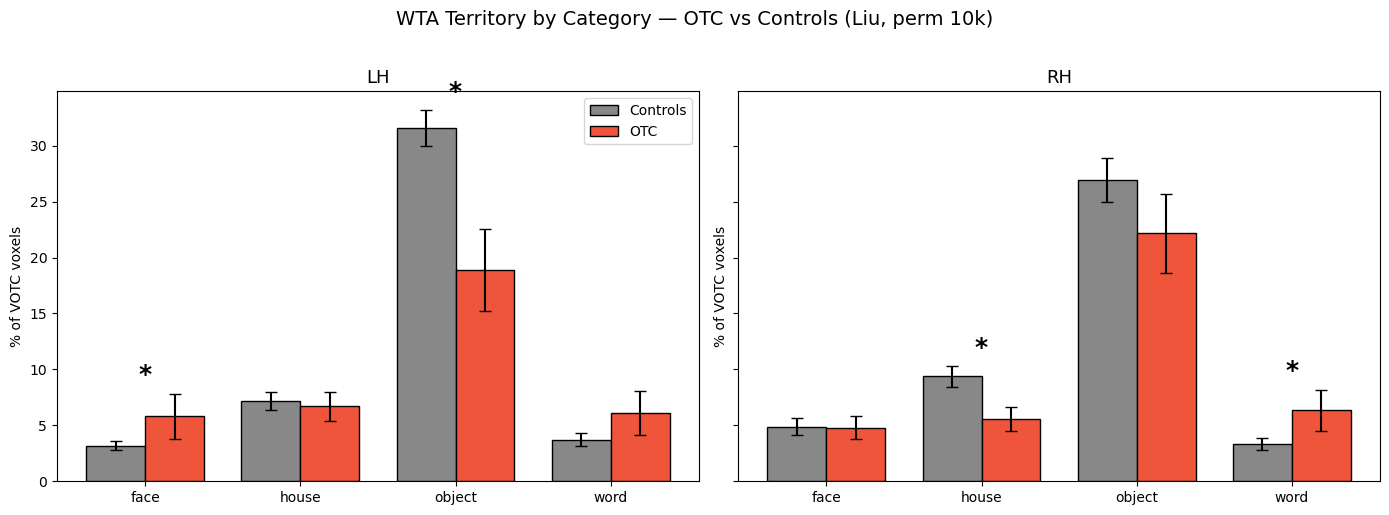

In [5]:
# Bar plot: per-category territory by group × hemi
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, h, label in zip(axes, ['l', 'r'], ['LH', 'RH']):
    ctrl_means = []; ctrl_sems = []
    otc_means = [];  otc_sems = []
    for cat in CATEGORIES:
        c = terr_df[(terr_df['group'] == 'control') &
                    (terr_df['hemi'] == h) &
                    (terr_df['category'] == cat)]['pct']
        o = terr_df[(terr_df['group'] == 'OTC') &
                    (terr_df['hemi'] == h) &
                    (terr_df['category'] == cat)]['pct']
        ctrl_means.append(c.mean()); ctrl_sems.append(c.sem())
        otc_means.append(o.mean());  otc_sems.append(o.sem())

    x = np.arange(len(CATEGORIES))
    w = 0.38
    ax.bar(x - w/2, ctrl_means, w, yerr=ctrl_sems, capsize=4,
           label='Controls', color='#888888', edgecolor='black')
    ax.bar(x + w/2, otc_means, w, yerr=otc_sems, capsize=4,
           label='OTC', color='#EF553B', edgecolor='black')

    # Mark significance from terr_results
    for i, cat in enumerate(CATEGORIES):
        row = terr_results_df[(terr_results_df['hemi'] == label) &
                              (terr_results_df['category'] == cat)].iloc[0]
        if row['p_perm'] < .05:
            ymax = max(ctrl_means[i] + ctrl_sems[i], otc_means[i] + otc_sems[i])
            ax.text(i, ymax + 1, '*', fontsize=18, ha='center', fontweight='bold')

    ax.set_xticks(x); ax.set_xticklabels(CATEGORIES)
    ax.set_ylabel('% of VOTC voxels')
    ax.set_title(label, fontsize=13)
    if h == 'l': ax.legend()

plt.suptitle('WTA Territory by Category — OTC vs Controls (Liu, perm 10k)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'territory_xs_perm_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

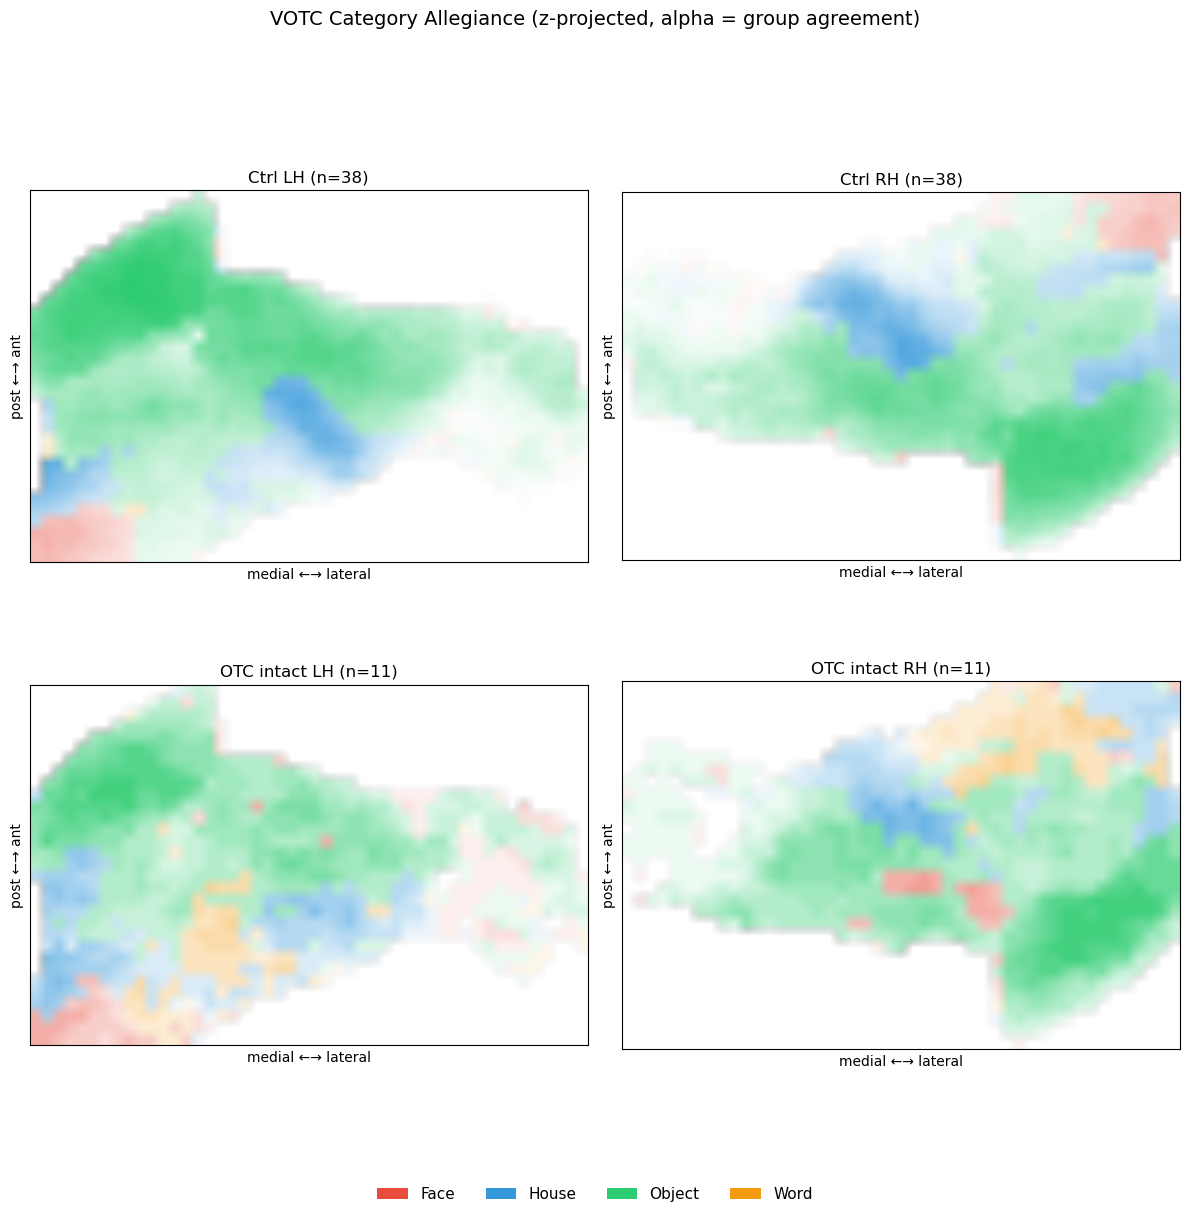

In [6]:
# ── VOTC watercolor: 2D projection of WTA territory per group ─────────
# Per voxel: mode category across group (color), agreement % (saturation/alpha)

from matplotlib.colors import to_rgb

CAT_RGB = {1: to_rgb('#E74C3C'),   # face
           2: to_rgb('#3498DB'),   # house
           3: to_rgb('#2ECC71'),   # object
           4: to_rgb('#F39C12')}   # word

def group_watercolor(group, hemi, axis='z'):
    """For each voxel: category mode + agreement % across subjects in group.
    Project to 2D by max-agreement along given axis."""
    mask = get_votc_mask(hemi)
    n_vox = int(mask.sum())

    votes = np.zeros((n_vox, 5), dtype=int)
    n_subs = 0
    for (sid, h), d in wta_data.items():
        if d['group'] != group or h != hemi:
            continue
        for c in range(5):
            votes[:, c] += (d['winner'] == c).astype(int)
        n_subs += 1
    if n_subs == 0:
        return None, None, 0

    # Mode + agreement (excluding 'none')
    cat_votes = votes[:, 1:]
    winner_1d = cat_votes.argmax(axis=1) + 1
    agreement_1d = cat_votes.max(axis=1) / n_subs

    # Inflate back to 3D
    winner_3d = np.zeros(MNI_SHAPE, dtype=int)
    agree_3d  = np.zeros(MNI_SHAPE, dtype=float)
    winner_3d[mask] = winner_1d
    agree_3d[mask]  = agreement_1d

    # 2D projection: at each (y, x), pick voxel with highest agreement along axis
    if axis == 'z':
        # ventral view — project along z, rows=y (post→ant), cols=x
        idx_max = np.argmax(agree_3d, axis=2)
        yi, xi = np.indices(idx_max.shape)
        cat_2d = winner_3d[yi, xi, idx_max]
        agr_2d = agree_3d[yi, xi, idx_max]
    elif axis == 'y':
        idx_max = np.argmax(agree_3d, axis=1)
        zi, xi = np.indices(idx_max.shape)
        cat_2d = winner_3d[zi[:, np.newaxis], idx_max, xi[:, np.newaxis]]
        # ^ messy; stick with z projection for now
        raise NotImplementedError
    return cat_2d, agr_2d, n_subs


def render_watercolor(cat_2d, agr_2d, ax, title, flip_x=False):
    """Build RGBA image: category color, alpha=agreement."""
    rgba = np.zeros((*cat_2d.shape, 4))
    for c, rgb in CAT_RGB.items():
        m = cat_2d == c
        rgba[m, 0] = rgb[0]
        rgba[m, 1] = rgb[1]
        rgba[m, 2] = rgb[2]
        rgba[m, 3] = agr_2d[m]   # alpha = agreement
    # Tighten to non-empty bounding box
    nz_y = np.where(rgba[..., 3].any(axis=1))[0]
    nz_x = np.where(rgba[..., 3].any(axis=0))[0]
    if len(nz_y) and len(nz_x):
        rgba = rgba[nz_y.min():nz_y.max()+1, nz_x.min():nz_x.max()+1]
    if flip_x:
        rgba = rgba[:, ::-1]
    # Origin: y=posterior (low) at bottom, anterior (high) at top
    ax.imshow(rgba, origin='lower', interpolation='bilinear', aspect='equal')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('medial ←→ lateral')
    ax.set_ylabel('post ←→ ant')
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(2, 2, figsize=(12, 12))
panels = [
    (axes[0, 0], 'Ctrl LH',         'control', 'l', False),
    (axes[0, 1], 'Ctrl RH',         'control', 'r', True),
    (axes[1, 0], 'OTC intact LH',   'OTC',     'l', False),
    (axes[1, 1], 'OTC intact RH',   'OTC',     'r', True),
]
for ax, title, group, hemi, flip in panels:
    cat_2d, agr_2d, n = group_watercolor(group, hemi, axis='z')
    if cat_2d is None:
        ax.set_title(f'{title} (no data)'); ax.axis('off'); continue
    render_watercolor(cat_2d, agr_2d, ax, f'{title} (n={n})', flip_x=flip)

# Legend
legend = [Patch(facecolor=CAT_RGB[c+1], label=cat.capitalize())
          for c, cat in enumerate(CATEGORIES)]
fig.legend(handles=legend, loc='lower center', ncol=4,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('VOTC Category Allegiance (z-projected, alpha = group agreement)',
             fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(os.path.join(FIG_DIR, 'votc_watercolor_xs_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

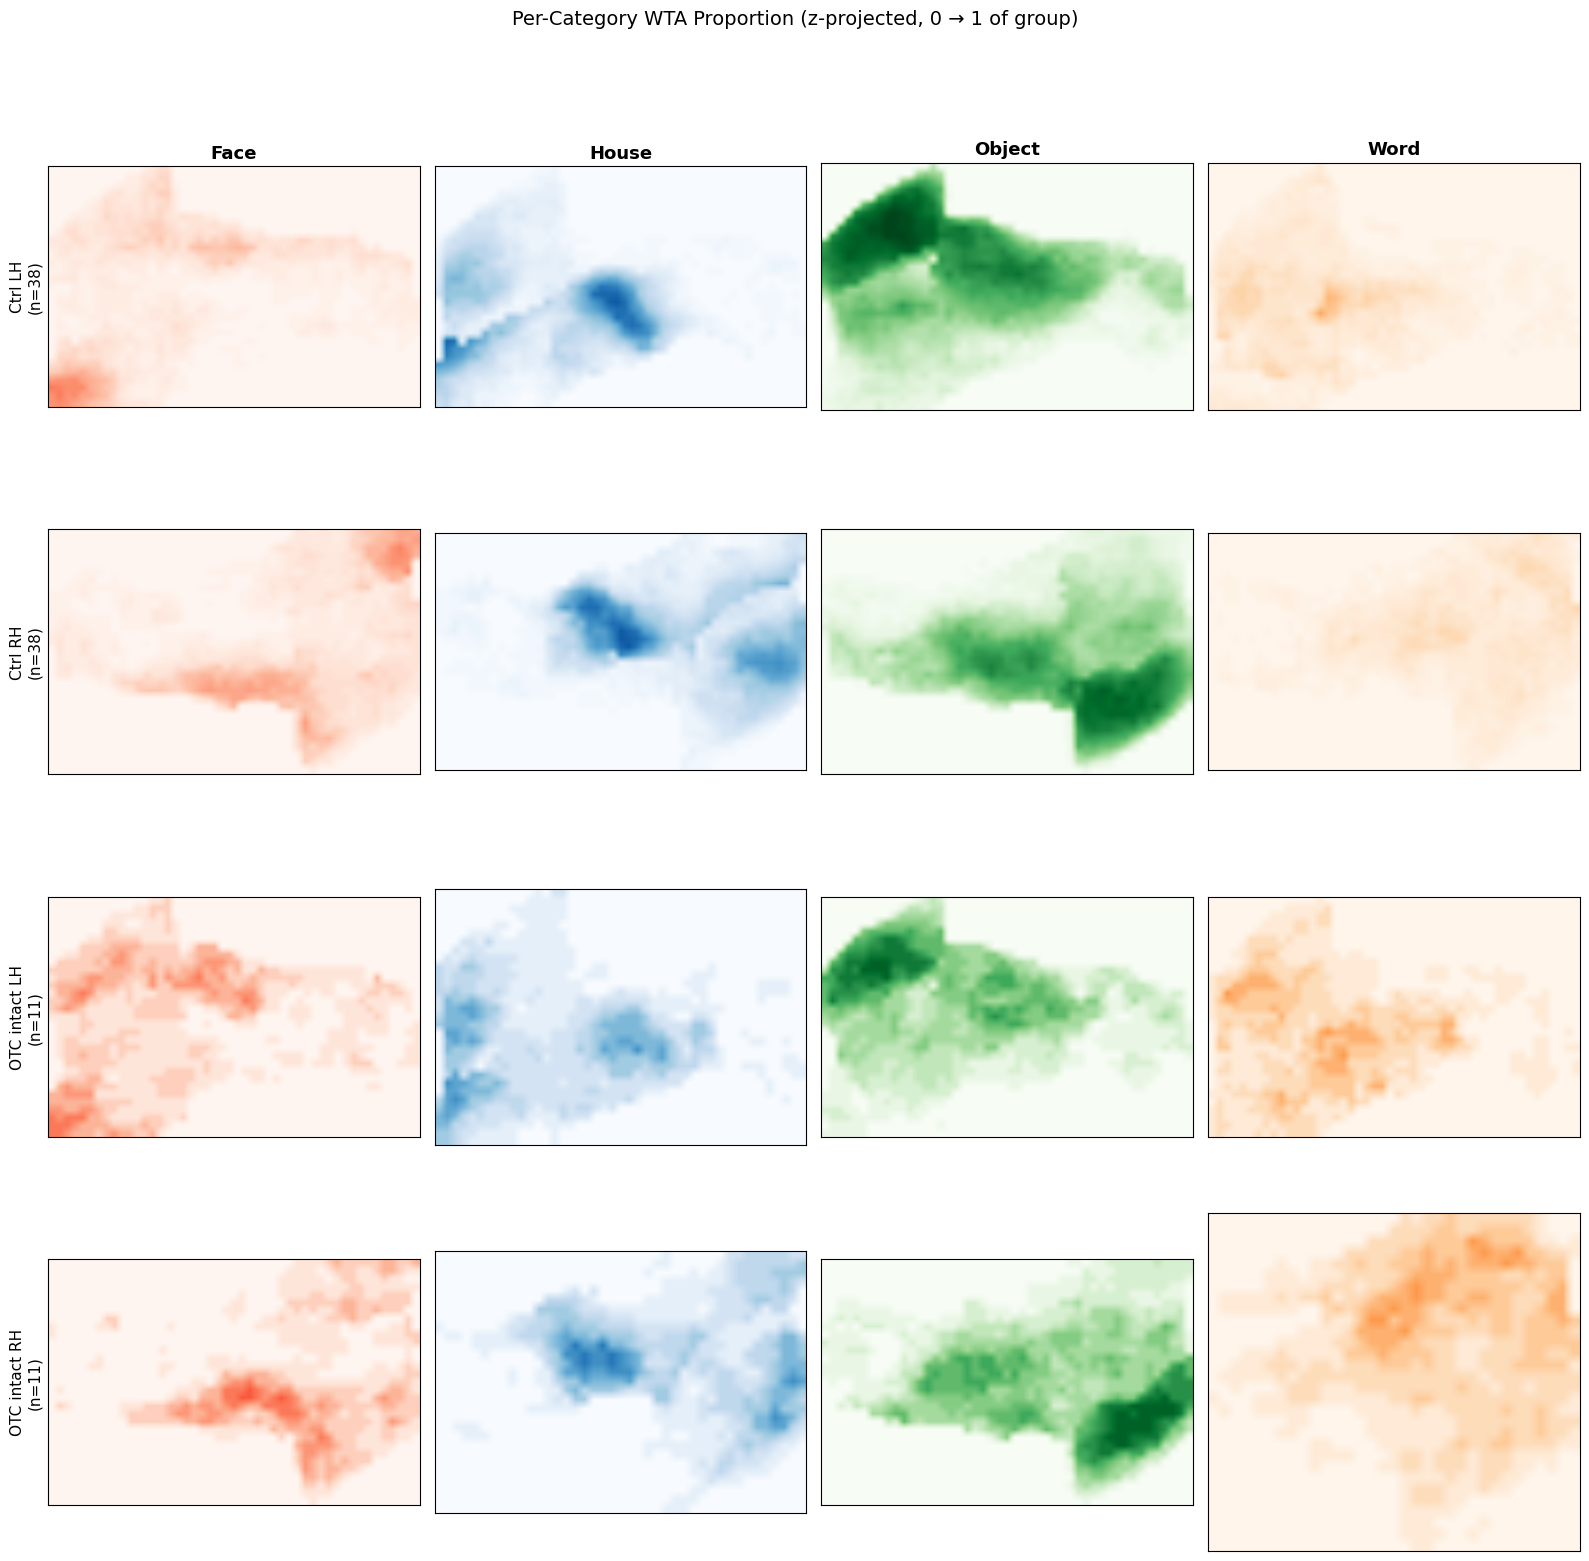

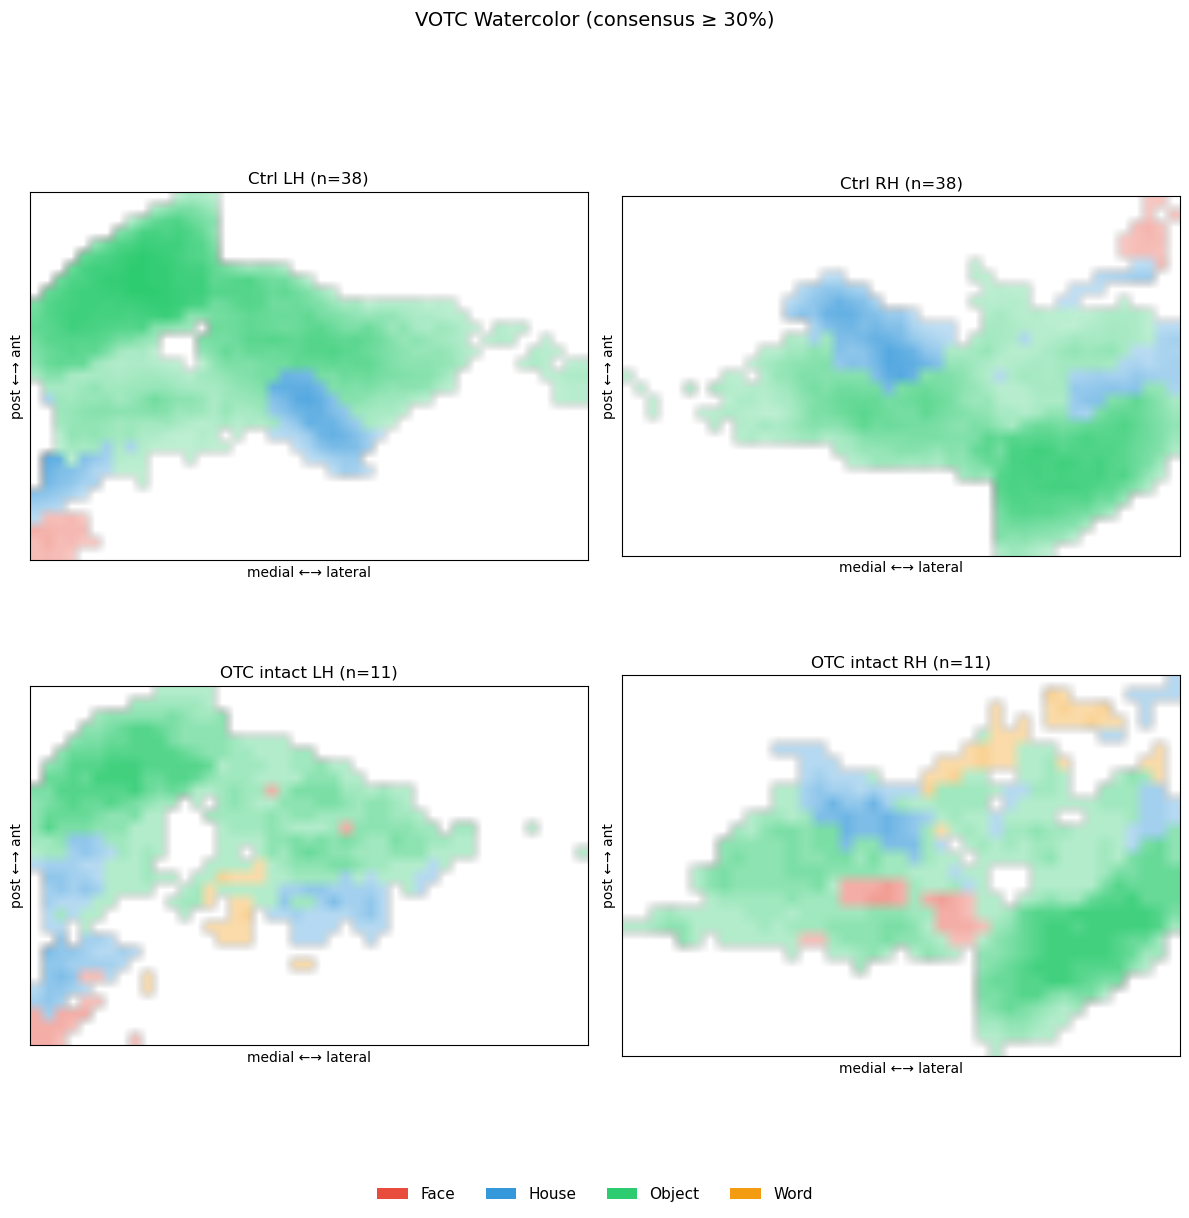

In [7]:
# ── Per-category proportion maps + lower-threshold consensus ──────────────────
# Two visualizations:
# (1) Per-category panels: how often each category wins per voxel, per group
# (2) Watercolor with consensus threshold lowered to 30%

CAT_CMAPS = {1: 'Reds', 2: 'Blues', 3: 'Greens', 4: 'Oranges'}
CAT_NAMES = {1: 'face', 2: 'house', 3: 'object', 4: 'word'}


def group_proportion_3d(group, hemi):
    """Per-voxel per-category vote proportions across subjects in group."""
    mask = get_votc_mask(hemi)
    n_vox = int(mask.sum())
    votes = np.zeros((n_vox, 5), dtype=int)
    n_subs = 0
    for (sid, h), d in wta_data.items():
        if d['group'] != group or h != hemi:
            continue
        for c in range(5):
            votes[:, c] += (d['winner'] == c).astype(int)
        n_subs += 1
    if n_subs == 0:
        return None, 0

    # Inflate per-category proportion to 3D
    prop_3d = {}
    for c in range(1, 5):
        p = np.zeros(MNI_SHAPE, dtype=float)
        p[mask] = votes[:, c] / n_subs
        prop_3d[c] = p
    return prop_3d, n_subs


def project_proportion_2d(prop_3d_cat, axis=2):
    """Max projection of a single-category proportion volume."""
    proj = prop_3d_cat.max(axis=axis)
    return proj


# ── Figure 1: Per-category proportion maps, 4 groups × 4 categories ───────────
groups_panels = [
    ('Ctrl LH',       'control', 'l', False),
    ('Ctrl RH',       'control', 'r', True),
    ('OTC intact LH', 'OTC',     'l', False),
    ('OTC intact RH', 'OTC',     'r', True),
]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for row_idx, (gname, group, hemi, flip_x) in enumerate(groups_panels):
    prop_3d, n = group_proportion_3d(group, hemi)
    if prop_3d is None:
        for ax in axes[row_idx]:
            ax.axis('off')
        continue
    for col_idx, cat in enumerate([1, 2, 3, 4]):
        ax = axes[row_idx, col_idx]
        proj = project_proportion_2d(prop_3d[cat])
        # Crop to non-zero
        nz_y = np.where(proj.any(axis=1))[0]
        nz_x = np.where(proj.any(axis=0))[0]
        if len(nz_y) and len(nz_x):
            proj = proj[nz_y.min():nz_y.max()+1, nz_x.min():nz_x.max()+1]
        if flip_x:
            proj = proj[:, ::-1]
        im = ax.imshow(proj, origin='lower', cmap=CAT_CMAPS[cat],
                        vmin=0, vmax=1, interpolation='bilinear', aspect='equal')
        if row_idx == 0:
            ax.set_title(CAT_NAMES[cat].capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(f'{gname}\n(n={n})', fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Per-Category WTA Proportion (z-projected, 0 → 1 of group)',
             fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(FIG_DIR, 'votc_per_category_xs_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2: Watercolor with consensus threshold = 30% ───────────────────────
# Same as group_watercolor() but agreement threshold mask
def group_watercolor_thresh(group, hemi, agree_thresh=0.3):
    """Watercolor but only show voxels where winning category exceeds agree_thresh."""
    mask = get_votc_mask(hemi)
    n_vox = int(mask.sum())
    votes = np.zeros((n_vox, 5), dtype=int)
    n_subs = 0
    for (sid, h), d in wta_data.items():
        if d['group'] != group or h != hemi:
            continue
        for c in range(5):
            votes[:, c] += (d['winner'] == c).astype(int)
        n_subs += 1
    if n_subs == 0:
        return None, None, 0

    cat_votes = votes[:, 1:]
    winner_1d = cat_votes.argmax(axis=1) + 1
    agreement_1d = cat_votes.max(axis=1) / n_subs

    # Mask out voxels below agreement threshold
    keep = agreement_1d >= agree_thresh
    winner_1d = np.where(keep, winner_1d, 0)
    agreement_1d = np.where(keep, agreement_1d, 0)

    winner_3d = np.zeros(MNI_SHAPE, dtype=int)
    agree_3d  = np.zeros(MNI_SHAPE, dtype=float)
    winner_3d[mask] = winner_1d
    agree_3d[mask]  = agreement_1d

    idx_max = np.argmax(agree_3d, axis=2)
    yi, xi = np.indices(idx_max.shape)
    cat_2d = winner_3d[yi, xi, idx_max]
    agr_2d = agree_3d[yi, xi, idx_max]
    return cat_2d, agr_2d, n_subs


AGREE_THRESH = 0.3

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, (title, group, hemi, flip) in zip(axes.flat, [
    ('Ctrl LH',       'control', 'l', False),
    ('Ctrl RH',       'control', 'r', True),
    ('OTC intact LH', 'OTC',     'l', False),
    ('OTC intact RH', 'OTC',     'r', True),
]):
    cat_2d, agr_2d, n = group_watercolor_thresh(group, hemi, AGREE_THRESH)
    if cat_2d is None:
        ax.set_title(f'{title} (no data)'); ax.axis('off'); continue
    render_watercolor(cat_2d, agr_2d, ax, f'{title} (n={n})', flip_x=flip)

legend = [Patch(facecolor=CAT_RGB[c+1], label=cat.capitalize())
          for c, cat in enumerate(CATEGORIES)]
fig.legend(handles=legend, loc='lower center', ncol=4,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))
plt.suptitle(f'VOTC Watercolor (consensus ≥ {int(AGREE_THRESH*100)}%)',
             fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(os.path.join(FIG_DIR, f'votc_watercolor_thresh{int(AGREE_THRESH*100)}_xs_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

Computing voxel-demeaned raw beta correlations...


  98 sub-hemi entries

VOXEL-DEMEANED RAW BETA CORRELATION — perm test (OTC vs control)
Negative r = categories occupy distinct voxel populations
Positive r = categories share voxel populations

  Hemi            Pair   Ctrl r    OTC r        Δ        p  Sig
-----------------------------------------------------------------
    LH      face_house   -0.338   -0.409   -0.071   0.1598     
    LH     face_object   -0.481   -0.336    0.146   0.0191    *
    LH       face_word   -0.081   -0.124   -0.042   0.5792     
    LH    house_object   -0.216   -0.144    0.072   0.2498     
    LH      house_word   -0.547   -0.496    0.051   0.3266     
    LH     object_word   -0.289   -0.424   -0.135   0.0457    *
    RH      face_house   -0.363   -0.443   -0.080   0.1451     
    RH     face_object   -0.321   -0.346   -0.025   0.6847     
    RH       face_word   -0.176   -0.140    0.036   0.5767     
    RH    house_object   -0.094   -0.077    0.017   0.8109     
    RH      house_word   -0.573   -

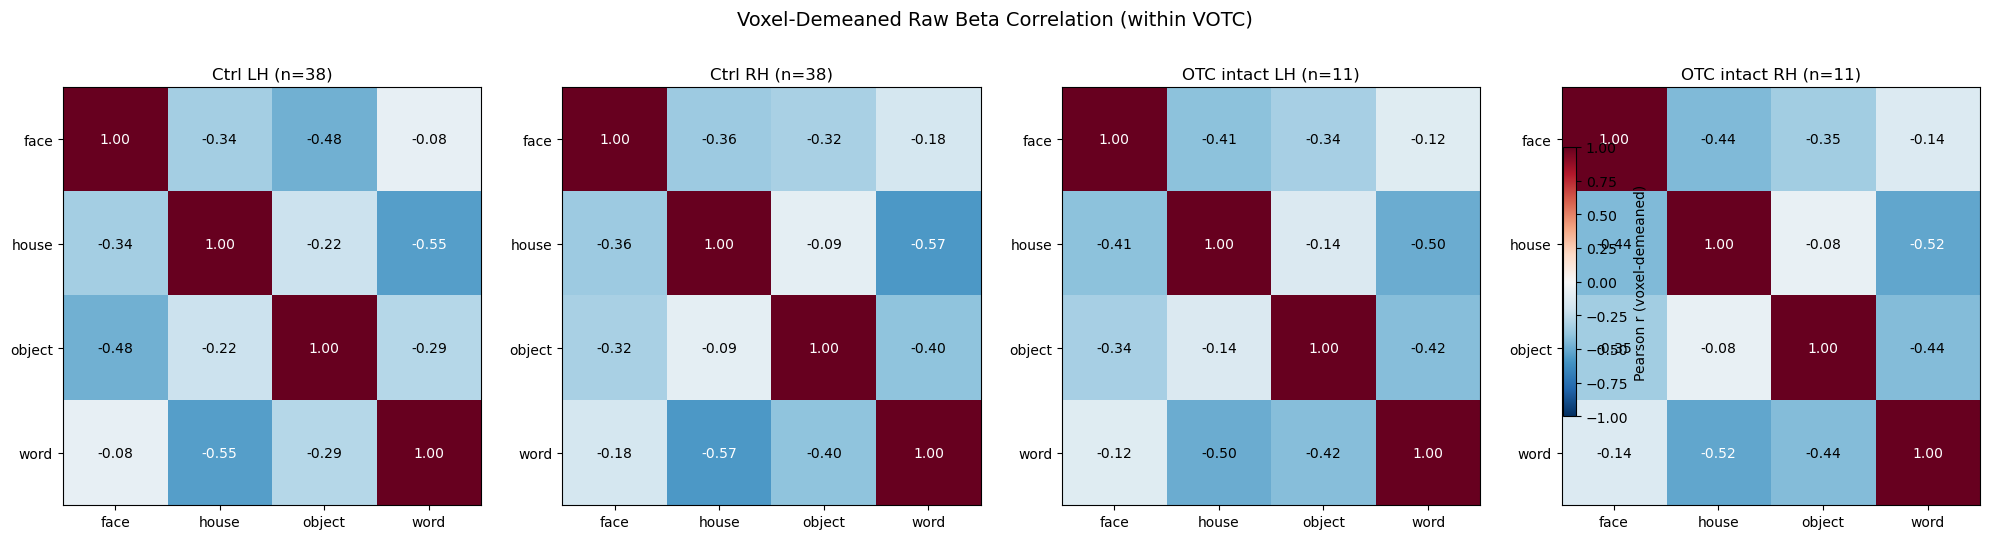

In [8]:
# ── Raw beta correlations (voxel-demeaned) ───────────────────────────────────
# Per voxel: subtract mean across 4 categories before correlating.
# Removes shared visual-activation baseline; isolates category-tuning structure.

RAW_BETA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}


def get_mni_cope_path(sub_id, session, cope_num):
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    return os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats',
                        'cope1_mni.nii.gz')


def load_raw_betas_demeaned(sub_id, session, mask):
    """Load 4 raw-beta copes within mask, demean each voxel across categories."""
    betas = {}
    for cat, cope_num in RAW_BETA_COPES.items():
        path = get_mni_cope_path(sub_id, session, cope_num)
        if not os.path.exists(path):
            return None
        data = nib.load(path).get_fdata()
        betas[cat] = data[mask]

    # Stack: (n_voxels, 4_categories), demean each row
    mat = np.column_stack([betas[c] for c in CATEGORIES])
    mat = mat - mat.mean(axis=1, keepdims=True)
    return {cat: mat[:, i] for i, cat in enumerate(CATEGORIES)}


print('Computing voxel-demeaned raw beta correlations...')
beta_corr_rows = []
PAIRS = [('face', 'house'), ('face', 'object'), ('face', 'word'),
         ('house', 'object'), ('house', 'word'), ('object', 'word')]

for sid, info in subjects.items():
    ses = info['session']
    hemis = ['l', 'r'] if info['group'] == 'control' else [info['hemi']]
    for h in hemis:
        mask = get_votc_mask(h)
        betas = load_raw_betas_demeaned(sid, ses, mask)
        if betas is None:
            continue
        row = {'sub': sid, 'hemi': h, 'group': info['group'],
               'surgery_side': info.get('surgery_side', 'na')}
        for c1, c2 in PAIRS:
            r = np.corrcoef(betas[c1], betas[c2])[0, 1]
            row[f'{c1}_{c2}'] = r
        beta_corr_rows.append(row)

beta_corr_df = pd.DataFrame(beta_corr_rows)
print(f'  {len(beta_corr_df)} sub-hemi entries')

print('\n' + '=' * 78)
print('VOXEL-DEMEANED RAW BETA CORRELATION — perm test (OTC vs control)')
print('Negative r = categories occupy distinct voxel populations')
print('Positive r = categories share voxel populations')
print('=' * 78)
print(f'\n{"Hemi":>6} {"Pair":>15} {"Ctrl r":>8} {"OTC r":>8} {"Δ":>8} {"p":>8} {"Sig":>4}')
print('-' * 65)

corr_results = []
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    for c1, c2 in PAIRS:
        col = f'{c1}_{c2}'
        ctrl_v = beta_corr_df[(beta_corr_df['group'] == 'control') &
                               (beta_corr_df['hemi'] == h)][col].dropna().values
        otc_v  = beta_corr_df[(beta_corr_df['group'] == 'OTC') &
                               (beta_corr_df['hemi'] == h)][col].dropna().values
        if len(otc_v) < 2 or len(ctrl_v) < 2: continue
        delta, p = perm_test(otc_v, ctrl_v)
        sig = '*' if p < .05 else ('†' if p < .10 else '')
        corr_results.append({'hemi': label, 'pair': f'{c1}_{c2}',
                             'ctrl_r': ctrl_v.mean(), 'otc_r': otc_v.mean(),
                             'delta': delta, 'p_perm': p,
                             'n_ctrl': len(ctrl_v), 'n_otc': len(otc_v)})
        print(f'{label:>6} {col:>15} {ctrl_v.mean():>8.3f} {otc_v.mean():>8.3f} '
              f'{delta:>8.3f} {p:>8.4f} {sig:>4}')

corr_results_df = pd.DataFrame(corr_results)
corr_results_df.to_csv(os.path.join(OUT_DIR, 'raw_beta_corr_demeaned_xs_perm_liu.csv'),
                       index=False)


# ── 4×4 RDM-style heatmaps per group × hemi ──────────────────────────────────
def build_corr_matrix(group, hemi):
    sub_mats = []
    for _, row in beta_corr_df[(beta_corr_df['group'] == group) &
                                (beta_corr_df['hemi'] == hemi)].iterrows():
        m = np.eye(4)
        for c1, c2 in PAIRS:
            i = CATEGORIES.index(c1); j = CATEGORIES.index(c2)
            m[i, j] = m[j, i] = row[f'{c1}_{c2}']
        sub_mats.append(m)
    if not sub_mats:
        return None, 0
    return np.mean(sub_mats, axis=0), len(sub_mats)


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
panels = [
    ('Ctrl LH',       'control', 'l'),
    ('Ctrl RH',       'control', 'r'),
    ('OTC intact LH', 'OTC',     'l'),
    ('OTC intact RH', 'OTC',     'r'),
]
for ax, (title, group, hemi) in zip(axes, panels):
    mat, n = build_corr_matrix(group, hemi)
    if mat is None:
        ax.set_title(f'{title} (no data)'); ax.axis('off'); continue
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CATEGORIES); ax.set_yticklabels(CATEGORIES)
    ax.set_title(f'{title} (n={n})')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    color='white' if abs(mat[i, j]) > 0.5 else 'black',
                    fontsize=10)

plt.colorbar(im, ax=axes, shrink=0.7, label='Pearson r (voxel-demeaned)')
plt.suptitle('Voxel-Demeaned Raw Beta Correlation (within VOTC)',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'raw_beta_corr_demeaned_xs_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 2. Pairwise category neighborhood — boundary preservation

For each voxel labeled X in subject S, count what fraction of its 6-connected
WTA-labeled neighbors are each category. Average across voxels → 4×4 neighbor
matrix per subject. Compare patient vs control matrices.

In [9]:
def compute_neighbor_matrix(winner_3d):
    """6-connected neighbor matrix. neighbor[i,j] = count of i-labeled voxels
    whose neighbors are j-labeled. Self excluded."""
    nbr = np.zeros((4, 4), dtype=float)
    self_counts = np.zeros(4, dtype=float)
    shifts = [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]

    for i_cat in range(1, 5):
        own = (winner_3d == i_cat)
        if not own.any():
            continue
        for j_cat in range(1, 5):
            other = (winner_3d == j_cat)
            count = 0
            for dx, dy, dz in shifts:
                shifted = np.roll(other, (dx, dy, dz), axis=(0, 1, 2))
                count += int((own & shifted).sum())
            if i_cat == j_cat:
                # exclude self by subtracting own-own; but for boundary purposes
                # we want non-self neighbors. Drop diagonal or keep — keep for now.
                nbr[i_cat - 1, j_cat - 1] = count
                self_counts[i_cat - 1] = own.sum()
            else:
                nbr[i_cat - 1, j_cat - 1] = count
        # Normalize row by total neighbors (so row sums to 1 → probabilities)
        row_total = nbr[i_cat - 1].sum()
        if row_total > 0:
            nbr[i_cat - 1] /= row_total
    return nbr


# Reconstruct 3D winner per subject for neighbor calc
def winner_to_3d(winner_1d, mask):
    vol = np.zeros(MNI_SHAPE, dtype=int)
    vol[mask] = winner_1d
    return vol


print('Computing neighbor matrices...')
neighbor_mats = {}
for (sid, h), d in wta_data.items():
    mask = get_votc_mask(h)
    winner_3d = winner_to_3d(d['winner'], mask)
    neighbor_mats[(sid, h)] = compute_neighbor_matrix(winner_3d)
print(f'  {len(neighbor_mats)} subjects done')

Computing neighbor matrices...
  98 subjects done


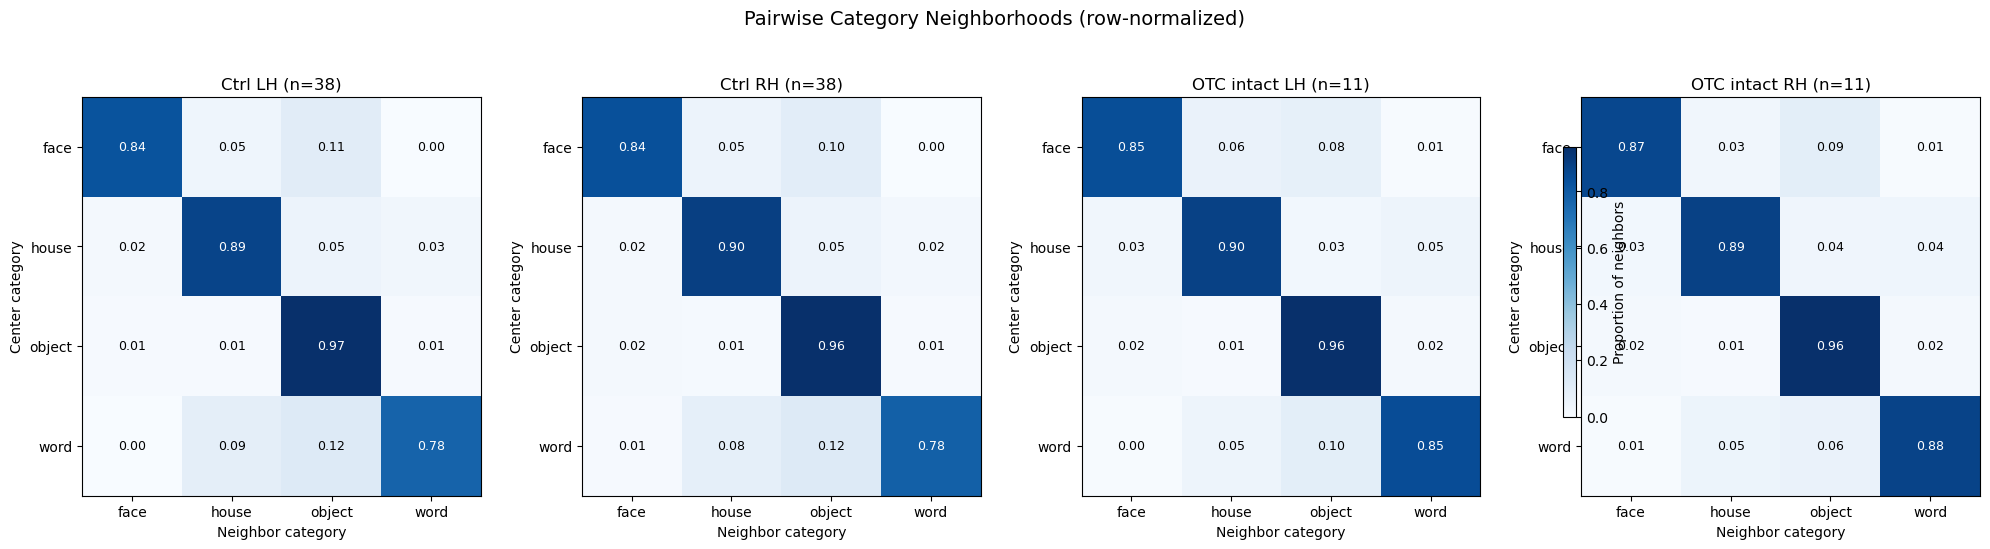

In [10]:
# Group means: ctrl LH, ctrl RH, OTC intact-LH, OTC intact-RH
def avg_mat(group, hemi):
    mats = [neighbor_mats[(sid, h)]
            for (sid, h), d in wta_data.items()
            if d['group'] == group and h == hemi]
    return np.mean(mats, axis=0) if mats else None, len(mats)

panels = [
    ('Ctrl LH', 'control', 'l'),
    ('Ctrl RH', 'control', 'r'),
    ('OTC intact LH', 'OTC', 'l'),
    ('OTC intact RH', 'OTC', 'r'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, group, hemi) in zip(axes, panels):
    mat, n = avg_mat(group, hemi)
    if mat is None:
        ax.set_title(f'{title} (no data)'); ax.axis('off'); continue
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=mat.max())
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(CATEGORIES); ax.set_yticklabels(CATEGORIES)
    ax.set_xlabel('Neighbor category'); ax.set_ylabel('Center category')
    ax.set_title(f'{title} (n={n})')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    color='white' if mat[i, j] > mat.max()/2 else 'black',
                    fontsize=9)

plt.colorbar(im, ax=axes, shrink=0.7, label='Proportion of neighbors')
plt.suptitle('Pairwise Category Neighborhoods (row-normalized)',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'neighbor_matrices_xs_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Per-cell perm test: OTC vs control, per hemi
print('=' * 78)
print('NEIGHBOR MATRIX — perm test (OTC vs ctrl) per cell × hemisphere')
print('=' * 78)

nbr_results = []
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    print(f'\n  {label}:')
    print(f'  {"Center":>8} {"Neighbor":>9} {"Ctrl":>7} {"OTC":>7} '
          f'{"Δ":>7} {"p":>8} {"Sig":>4}')
    for i, ic in enumerate(CATEGORIES):
        for j, jc in enumerate(CATEGORIES):
            ctrl_v = [neighbor_mats[(sid, h)][i, j]
                      for (sid, hh), d in wta_data.items()
                      if d['group'] == 'control' and hh == h
                      and (sid, h) in neighbor_mats]
            otc_v  = [neighbor_mats[(sid, h)][i, j]
                      for (sid, hh), d in wta_data.items()
                      if d['group'] == 'OTC' and hh == h
                      and (sid, h) in neighbor_mats]
            delta, p = perm_test(otc_v, ctrl_v)
            sig = '*' if p < .05 else ('†' if p < .10 else '')
            nbr_results.append({'hemi': label, 'center': ic, 'neighbor': jc,
                                'ctrl_m': np.mean(ctrl_v),
                                'otc_m': np.mean(otc_v),
                                'delta': delta, 'p_perm': p})
            if p < .10:
                print(f'  {ic:>8} {jc:>9} {np.mean(ctrl_v):>7.3f} {np.mean(otc_v):>7.3f} '
                      f'{delta:>+7.3f} {p:>8.4f} {sig:>4}')

nbr_results_df = pd.DataFrame(nbr_results)
nbr_results_df.to_csv(os.path.join(OUT_DIR, 'neighbor_xs_perm_liu.csv'), index=False)
print(f'\nFull table saved: neighbor_xs_perm_liu.csv')

NEIGHBOR MATRIX — perm test (OTC vs ctrl) per cell × hemisphere

  LH:
    Center  Neighbor    Ctrl     OTC       Δ        p  Sig
      face      word   0.002   0.007  +0.005   0.0832    †
     house    object   0.053   0.027  -0.026   0.0326    *
    object      face   0.008   0.016  +0.008   0.0026    *
    object    object   0.972   0.961  -0.012   0.0124    *

  RH:
    Center  Neighbor    Ctrl     OTC       Δ        p  Sig
      face      word   0.002   0.007  +0.004   0.0587    †
    object      word   0.009   0.016  +0.007   0.0383    *
      word      word   0.783   0.883  +0.100   0.0450    *

Full table saved: neighbor_xs_perm_liu.csv


## 3. Control-defined territory displacement

Build a control consensus map per hemi: voxel labeled X if >50% of controls
prefer X. For each patient, compute what fraction of each control-X territory
is now Y in the patient. Tests territory boundary stability.

In [12]:
# Control consensus map per hemi
def control_consensus(hemi, threshold_pct=50):
    """Per-voxel: most-voted category if vote% >= threshold_pct, else 0."""
    mask = get_votc_mask(hemi)
    n_vox_in_mask = int(mask.sum())
    votes = np.zeros((n_vox_in_mask, 5), dtype=int)  # 0=none, 1-4=cat
    n_ctrl = 0
    for sid in ctrl_sids:
        if (sid, hemi) not in wta_data:
            continue
        w = wta_data[(sid, hemi)]['winner']
        for c in range(5):
            votes[:, c] += (w == c).astype(int)
        n_ctrl += 1
    # Among non-zero categories
    cat_votes = votes[:, 1:]  # face,house,object,word
    max_votes = cat_votes.max(axis=1)
    winner = cat_votes.argmax(axis=1) + 1
    pct = max_votes / n_ctrl * 100
    consensus_1d = np.where(pct >= threshold_pct, winner, 0)
    return consensus_1d, n_ctrl


CONSENSUS_THRESH = 50  # ≥50% of controls agree
ctrl_consensus = {}
for h in ['l', 'r']:
    cons, n_ctrl = control_consensus(h, CONSENSUS_THRESH)
    ctrl_consensus[h] = cons
    print(f'\n{("LH" if h=="l" else "RH")} control consensus (≥{CONSENSUS_THRESH}% agreement, n={n_ctrl}):')
    for i, cat in enumerate(CATEGORIES):
        print(f'  {cat}: {int(np.sum(cons == i+1)):,} consensus voxels')


LH control consensus (≥50% agreement, n=38):
  face: 0 consensus voxels
  house: 144 consensus voxels
  object: 2,839 consensus voxels
  word: 0 consensus voxels

RH control consensus (≥50% agreement, n=38):
  face: 0 consensus voxels
  house: 227 consensus voxels
  object: 1,891 consensus voxels
  word: 0 consensus voxels


In [13]:
# Per-patient: where do control-defined territories go?
# For each control category X in hemi h, in patient P:
#   pct_retained = % of those voxels still labeled X
#   pct_to_Y     = % now labeled Y (Y != X)
#   pct_lost     = % now labeled 0 (subthreshold)

print('=' * 78)
print(f'TERRITORY DISPLACEMENT — control consensus (≥{CONSENSUS_THRESH}%) → patient')
print('=' * 78)

displ_rows = []
for (sid, h), d in wta_data.items():
    if d['group'] != 'OTC':
        continue
    cons = ctrl_consensus[h]
    pat = d['winner']
    for i, src_cat in enumerate(CATEGORIES):
        src_mask = (cons == i + 1)
        if src_mask.sum() == 0:
            continue
        pat_in_src = pat[src_mask]
        n_src = src_mask.sum()
        pct_retained = float(np.sum(pat_in_src == i + 1)) / n_src * 100
        pct_lost = float(np.sum(pat_in_src == 0)) / n_src * 100
        for j, dst_cat in enumerate(CATEGORIES):
            if j == i: continue
            pct = float(np.sum(pat_in_src == j + 1)) / n_src * 100
            displ_rows.append({
                'sub': sid, 'hemi': h,
                'src_cat': src_cat, 'dst_cat': dst_cat,
                'pct_displaced': pct, 'pct_retained': pct_retained,
                'pct_lost': pct_lost, 'n_src_voxels': int(n_src),
            })

# Also: control's own retention of consensus (sanity check)
ctrl_displ_rows = []
for sid in ctrl_sids:
    for h in ['l', 'r']:
        if (sid, h) not in wta_data:
            continue
        cons = ctrl_consensus[h]
        ctrl_w = wta_data[(sid, h)]['winner']
        for i, src_cat in enumerate(CATEGORIES):
            src_mask = (cons == i + 1)
            if src_mask.sum() == 0: continue
            in_src = ctrl_w[src_mask]
            n_src = src_mask.sum()
            pct_retained = float(np.sum(in_src == i + 1)) / n_src * 100
            for j, dst_cat in enumerate(CATEGORIES):
                if j == i: continue
                pct = float(np.sum(in_src == j + 1)) / n_src * 100
                ctrl_displ_rows.append({
                    'sub': sid, 'hemi': h, 'src_cat': src_cat, 'dst_cat': dst_cat,
                    'pct_displaced': pct, 'pct_retained': pct_retained,
                })

displ_df = pd.DataFrame(displ_rows)
ctrl_displ_df = pd.DataFrame(ctrl_displ_rows)

# Group means: retention per src category × hemi
print('\n--- Retention of control-consensus territory (% still own category) ---')
print(f'\n{"Hemi":>6} {"Cat":>8} {"Ctrl M":>8} {"OTC M":>8} {"Δ":>8} {"p":>8} {"Sig":>4}')
print('-' * 60)
ret_results = []
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    for cat in CATEGORIES:
        ctrl_v = ctrl_displ_df[(ctrl_displ_df['hemi'] == h) &
                               (ctrl_displ_df['src_cat'] == cat)]                     .drop_duplicates(subset=['sub', 'hemi'])['pct_retained'].values
        otc_v  = displ_df[(displ_df['hemi'] == h) &
                          (displ_df['src_cat'] == cat)]                     .drop_duplicates(subset=['sub', 'hemi'])['pct_retained'].values
        if len(otc_v) < 2 or len(ctrl_v) < 2:
            continue
        delta, p = perm_test(otc_v, ctrl_v)
        sig = '*' if p < .05 else ('†' if p < .10 else '')
        ret_results.append({'hemi': label, 'category': cat,
                            'ctrl_retention': ctrl_v.mean(),
                            'otc_retention': otc_v.mean(),
                            'delta': delta, 'p_perm': p,
                            'n_ctrl': len(ctrl_v), 'n_otc': len(otc_v)})
        print(f'{label:>6} {cat:>8} {ctrl_v.mean():>8.2f} {otc_v.mean():>8.2f} '
              f'{delta:>+8.2f} {p:>8.4f} {sig:>4}')

ret_results_df = pd.DataFrame(ret_results)
ret_results_df.to_csv(os.path.join(OUT_DIR, 'territory_retention_xs_perm_liu.csv'),
                       index=False)

TERRITORY DISPLACEMENT — control consensus (≥50%) → patient

--- Retention of control-consensus territory (% still own category) ---

  Hemi      Cat   Ctrl M    OTC M        Δ        p  Sig
------------------------------------------------------------
    LH    house    61.73    38.95   -22.78   0.0083    *
    LH   object    68.49    42.60   -25.89   0.0000    *
    RH    house    58.40    37.44   -20.96   0.0275    *
    RH   object    64.34    50.91   -13.43   0.0699    †


In [14]:
# Where does displaced territory go? Per-pair perm tests
print('\n--- Displacement targets (where does category X land in patients?) ---')
print(f'\n{"Hemi":>6} {"Source":>7} {"→":>3} {"Target":>7} {"Ctrl%":>7} {"OTC%":>7} '
      f'{"Δ":>7} {"p":>8} {"Sig":>4}')
print('-' * 70)

displ_results = []
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    for src in CATEGORIES:
        for dst in CATEGORIES:
            if src == dst: continue
            ctrl_v = ctrl_displ_df[(ctrl_displ_df['hemi'] == h) &
                                    (ctrl_displ_df['src_cat'] == src) &
                                    (ctrl_displ_df['dst_cat'] == dst)]                         ['pct_displaced'].values
            otc_v  = displ_df[(displ_df['hemi'] == h) &
                              (displ_df['src_cat'] == src) &
                              (displ_df['dst_cat'] == dst)]                         ['pct_displaced'].values
            if len(otc_v) < 2 or len(ctrl_v) < 2: continue
            delta, p = perm_test(otc_v, ctrl_v)
            sig = '*' if p < .05 else ('†' if p < .10 else '')
            displ_results.append({'hemi': label, 'src': src, 'dst': dst,
                                  'ctrl_m': ctrl_v.mean(), 'otc_m': otc_v.mean(),
                                  'delta': delta, 'p_perm': p})
            if p < .10:
                print(f'{label:>6} {src:>7} {"→":>3} {dst:>7} '
                      f'{ctrl_v.mean():>7.2f} {otc_v.mean():>7.2f} '
                      f'{delta:>+7.2f} {p:>8.4f} {sig:>4}')

displ_results_df = pd.DataFrame(displ_results)
displ_results_df.to_csv(os.path.join(OUT_DIR, 'displacement_xs_perm_liu.csv'),
                         index=False)
print(f'\nFull displacement table saved.')


--- Displacement targets (where does category X land in patients?) ---

  Hemi  Source   →  Target   Ctrl%    OTC%       Δ        p  Sig
----------------------------------------------------------------------
    LH   house   →    word    2.65    9.91   +7.26   0.0137    *
    LH  object   →    face    3.09    8.52   +5.43   0.0024    *
    RH  object   →   house    3.87    1.24   -2.63   0.0326    *

Full displacement table saved.


## 4. WTA margin distribution — group-level perm

In [15]:
# Per-subject mean margin per category × hemi
margin_rows = []
for (sid, h), d in wta_data.items():
    for i, cat in enumerate(CATEGORIES):
        cm = d['winner'] == i + 1
        if cm.sum() == 0:
            continue
        mean_marg = float(np.mean(d['margin'][cm]))
        margin_rows.append({'sub': sid, 'hemi': h, 'group': d['group'],
                            'category': cat, 'mean_margin': mean_marg,
                            'n_voxels': int(cm.sum())})

margin_df = pd.DataFrame(margin_rows)

print('=' * 78)
print('WTA MARGIN PER CATEGORY × HEMISPHERE — perm test (OTC vs control)')
print('Higher margin = more confident WTA assignment')
print('=' * 78)
print(f'\n{"Hemi":>6} {"Cat":>8} {"Ctrl M":>8} {"OTC M":>8} {"Δ":>8} {"p":>8} {"Sig":>4}')
print('-' * 60)

margin_results = []
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    for cat in CATEGORIES:
        ctrl_v = margin_df[(margin_df['group'] == 'control') &
                           (margin_df['hemi'] == h) &
                           (margin_df['category'] == cat)]['mean_margin'].values
        otc_v  = margin_df[(margin_df['group'] == 'OTC') &
                           (margin_df['hemi'] == h) &
                           (margin_df['category'] == cat)]['mean_margin'].values
        if len(otc_v) < 2 or len(ctrl_v) < 2: continue
        delta, p = perm_test(otc_v, ctrl_v)
        sig = '*' if p < .05 else ('†' if p < .10 else '')
        margin_results.append({'hemi': label, 'category': cat,
                               'ctrl_m': ctrl_v.mean(), 'otc_m': otc_v.mean(),
                               'delta': delta, 'p_perm': p,
                               'n_ctrl': len(ctrl_v), 'n_otc': len(otc_v)})
        print(f'{label:>6} {cat:>8} {ctrl_v.mean():>8.3f} {otc_v.mean():>8.3f} '
              f'{delta:>+8.3f} {p:>8.4f} {sig:>4}')

margin_results_df = pd.DataFrame(margin_results)
margin_results_df.to_csv(os.path.join(OUT_DIR, 'margin_xs_perm_liu.csv'),
                          index=False)

WTA MARGIN PER CATEGORY × HEMISPHERE — perm test (OTC vs control)
Higher margin = more confident WTA assignment

  Hemi      Cat   Ctrl M    OTC M        Δ        p  Sig
------------------------------------------------------------
    LH     face    1.910    2.089   +0.180   0.3891     
    LH    house    2.177    2.130   -0.047   0.8296     
    LH   object    4.245    3.559   -0.686   0.0335    *
    LH     word    1.357    1.583   +0.225   0.1543     
    RH     face    1.846    2.285   +0.439   0.0471    *
    RH    house    2.174    2.027   -0.147   0.4724     
    RH   object    3.903    3.716   -0.187   0.5552     
    RH     word    1.401    1.802   +0.401   0.0414    *


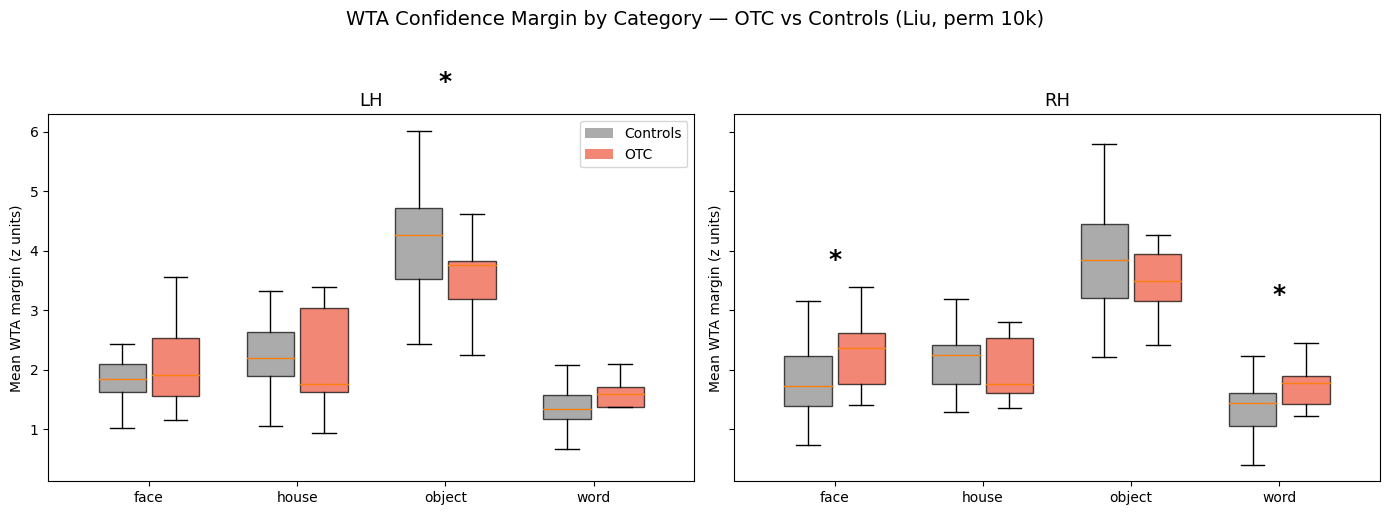

In [16]:
# Margin boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, h, label in zip(axes, ['l', 'r'], ['LH', 'RH']):
    positions, data, group_colors = [], [], []
    for i, cat in enumerate(CATEGORIES):
        c = margin_df[(margin_df['group'] == 'control') &
                      (margin_df['hemi'] == h) &
                      (margin_df['category'] == cat)]['mean_margin']
        o = margin_df[(margin_df['group'] == 'OTC') &
                      (margin_df['hemi'] == h) &
                      (margin_df['category'] == cat)]['mean_margin']
        positions.extend([i - 0.18, i + 0.18])
        data.extend([c.values, o.values])
        group_colors.extend(['#888888', '#EF553B'])

    bp = ax.boxplot(data, positions=positions, widths=0.32,
                    patch_artist=True, showfliers=False)
    for p, c in zip(bp['boxes'], group_colors):
        p.set_facecolor(c); p.set_alpha(0.7)

    # Significance markers
    for i, cat in enumerate(CATEGORIES):
        row = margin_results_df[(margin_results_df['hemi'] == label) &
                                 (margin_results_df['category'] == cat)]
        if len(row) and row.iloc[0]['p_perm'] < .05:
            ymax = max([d.max() for d in data[2*i:2*i+2] if len(d)])
            ax.text(i, ymax + 0.1, '*', fontsize=18, ha='center', fontweight='bold')

    ax.set_xticks(range(4)); ax.set_xticklabels(CATEGORIES)
    ax.set_ylabel('Mean WTA margin (z units)')
    ax.set_title(label, fontsize=13)

legend = [Patch(facecolor='#888888', alpha=0.7, label='Controls'),
          Patch(facecolor='#EF553B', alpha=0.7, label='OTC')]
axes[0].legend(handles=legend, loc='upper right')

plt.suptitle('WTA Confidence Margin by Category — OTC vs Controls (Liu, perm 10k)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'margin_xs_perm_liu.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Summary table

In [17]:
# Concatenate all perm test results into one summary
summary = pd.concat([
    terr_results_df.assign(analysis='territory_pct'),
    ret_results_df.assign(analysis='consensus_retention').rename(
        columns={'ctrl_retention': 'ctrl_m', 'otc_retention': 'otc_m'}),
    margin_results_df.assign(analysis='margin'),
], ignore_index=True)

summary = summary[['analysis', 'hemi', 'category', 'ctrl_m', 'otc_m',
                    'delta', 'p_perm', 'n_ctrl', 'n_otc']]
summary['p_fdr'] = summary['p_perm']  # placeholder; can apply FDR later
summary = summary.sort_values(['analysis', 'hemi', 'p_perm'])

out_path = os.path.join(OUT_DIR, 'voxel_allegiance_xs_summary_liu.csv')
summary.to_csv(out_path, index=False)
print(f'Saved: {out_path}\n')
print(summary.to_string(index=False))

Saved: /user_data/csimmon2/sym_pt/group_results/voxel_allegiance_liu/voxel_allegiance_xs_summary_liu.csv

           analysis hemi category    ctrl_m     otc_m      delta  p_perm  n_ctrl  n_otc  p_fdr
consensus_retention   LH   object 68.493354 42.604630 -25.888724  0.0000      38     11 0.0000
consensus_retention   LH    house 61.732456 38.952020 -22.780436  0.0083      38     11 0.0083
consensus_retention   RH    house 58.404823 37.444934 -20.959889  0.0275      38     11 0.0275
consensus_retention   RH   object 64.340783 50.906206 -13.434577  0.0699      38     11 0.0699
             margin   LH   object  4.245019  3.558612  -0.686407  0.0335      38     11 0.0335
             margin   LH     word  1.357034  1.582503   0.225469  0.1543      38     11 0.1543
             margin   LH     face  1.909599  2.089435   0.179836  0.3891      38     11 0.3891
             margin   LH    house  2.177097  2.130365  -0.046732  0.8296      38     11 0.8296
             margin   RH     word  1.40

## Notes

- All comparisons are **OTC vs control** only. nonOTC excluded at loader level.
- Perm tests: 10k iterations, seed 42, two-sided.
- Sample sizes per cell visible in `n_ctrl`, `n_otc` columns.
- Control consensus uses ≥50% agreement threshold; adjust `CONSENSUS_THRESH` if needed.
- For multiple comparison correction (e.g. FDR across all category × hemi tests), use the saved CSVs.

In [21]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

# Build SUB_CODES from sub_info.csv: code if available, else sub-XXX number
_info_df = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/sub_info.csv')
SUB_CODES = {row['sub']: (row['code'] if pd.notna(row['code']) and row['code'] != '' else row['sub'].replace('sub-', ''))
             for _, row in _info_df.drop_duplicates('sub').iterrows()}

# FDR: 'bh' = Benjamini-Hochberg (liberal); 'by' = Benjamini-Yekutieli (Liu's choice);
# None = disable correction.
FDR_METHOD = 'bh'

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')
print(f'FDR     : {FDR_METHOD}')


LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact
FDR     : bh


In [22]:
# Load selective voxel counts and run pt-vs-ctrl permutation tests per category × hemi × threshold
SELVOX_CSV = Path(processed_dir) / 'group_results' / 'roi_betas' / 'selective_voxel_counts.csv'
sv_df = pd.read_csv(SELVOX_CSV)
print(f'Loaded {len(sv_df)} rows')
print(f'Subjects: {sv_df["subject_id"].nunique()}')

# Permutation test (raw counts, no transformation)
def perm_count_diff(ctrl_v, pt_v, n_perm=10000, seed=42):
    ctrl_v, pt_v = np.asarray(ctrl_v, float), np.asarray(pt_v, float)
    if len(ctrl_v) < 3 or len(pt_v) < 2: return np.nan, np.nan
    obs = pt_v.mean() - ctrl_v.mean()
    pool = np.concatenate([ctrl_v, pt_v]); n_pt = len(pt_v)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
    return obs, (np.abs(null) >= abs(obs)).mean()

# Test 1: pt vs ctrl per category × hemi × threshold
# Patient subset: those whose intact hemi matches the test hemi
def get_pt_for_hemi(df, hemi):
    return df[(df['group']=='OTC') & (df['hemi']==hemi) &
              (((hemi=='l') & (df['intact_hemi']=='left')) |
               ((hemi=='r') & (df['intact_hemi']=='right')))]

print('\n=== Patient vs control: selective voxel counts ===\n')
print(f'{"Cat":>8s} {"Hemi":>5s} {"Thr":>5s} {"ctrl_M":>8s} {"pt_M":>8s} {"Δ":>8s} {"p":>8s}')
print('-' * 60)
sv_results = []
for cat in CATEGORIES:
    for h in ('l', 'r'):
        for t in [1.96, 2.33]:
            ct = sv_df[(sv_df['group']=='control') & (sv_df['category']==cat) &
                       (sv_df['hemi']==h) & (sv_df['threshold']==t)]['n_selective'].values
            pt_sub = get_pt_for_hemi(sv_df, h)
            pt = pt_sub[(pt_sub['category']==cat) & (pt_sub['threshold']==t)]['n_selective'].values
            d, p = perm_count_diff(ct, pt)
            flag = '*' if (not np.isnan(p) and p < 0.05) else ('†' if (not np.isnan(p) and p < 0.10) else '')
            print(f'{cat:>8s} {h:>5s} {t:>5.2f} {ct.mean():>8.0f} {pt.mean():>8.0f} '
                  f'{d:>+8.0f} {p:>8.4f} {flag}')
            sv_results.append({'category': cat, 'hemi': h, 'threshold': t,
                               'ctrl_mean': ct.mean(), 'pt_mean': pt.mean(),
                               'delta': d, 'p_perm': p,
                               'n_ctrl': len(ct), 'n_pt': len(pt)})
sv_results_df = pd.DataFrame(sv_results)
sv_results_df.to_csv(FIG_DIR / 'selvox_pt_vs_ctrl.csv', index=False)

Loaded 776 rows
Subjects: 59

=== Patient vs control: selective voxel counts ===

     Cat  Hemi   Thr   ctrl_M     pt_M        Δ        p
------------------------------------------------------------
    face     l  1.96     1288     1633     +345   0.2164 
    face     l  2.33     1032     1337     +306   0.2017 


    face     r  1.96     1888     1843      -44   0.9014 
    face     r  2.33     1556     1463      -93   0.7659 
   house     l  1.96     2576     2064     -512   0.1144 
   house     l  2.33     2185     1729     -457   0.1209 
   house     r  1.96     3084     2112     -972   0.0115 *
   house     r  2.33     2668     1825     -843   0.0170 *
  object     l  1.96     4024     2685    -1339   0.0026 *
  object     l  2.33     3492     2265    -1227   0.0035 *
  object     r  1.96     3496     2914     -583   0.2668 
  object     r  2.33     2981     2468     -513   0.3011 
    word     l  1.96     1465     1285     -180   0.5708 
    word     l  2.33     1152     1015     -136   0.6130 
    word     r  1.96      853     1725     +872   0.0071 *
    word     r  2.33      652     1369     +717   0.0081 *


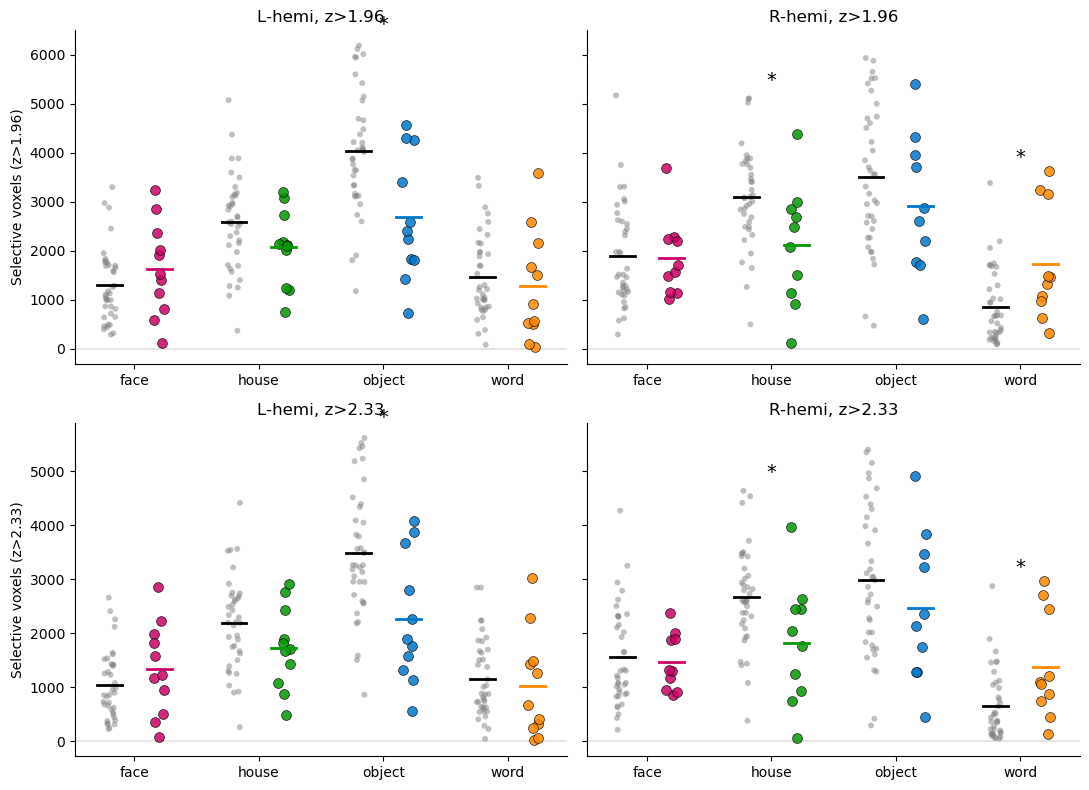

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey='row')
RNG = np.random.RandomState(42)

CAT_COLOR = {
    'face':   '#cc0066', 'face_STS':   '#cc0066',
    'house':  '#009900', 'house_TOS':  '#009900',
    'object':  '#0077cc', 'object_LOC': '#0077cc',
    'word':  '#ff8800', 'word_STG':   '#ff8800',
}

for row_i, t in enumerate([1.96, 2.33]):
    for col_i, h in enumerate(('l', 'r')):
        ax = axes[row_i, col_i]
        for xi, cat in enumerate(CATEGORIES):
            color = CAT_COLOR[cat]
            ct = sv_df[(sv_df['group']=='control') & (sv_df['category']==cat) &
                       (sv_df['hemi']==h) & (sv_df['threshold']==t)]['n_selective'].values
            pt_sub = get_pt_for_hemi(sv_df, h)
            pt = pt_sub[(pt_sub['category']==cat) & (pt_sub['threshold']==t)]['n_selective'].values
            
            ax.scatter([xi - 0.2] * len(ct) + RNG.uniform(-0.05, 0.05, len(ct)),
                       ct, s=18, color='gray', alpha=0.5, edgecolors='none', zorder=2)
            ax.plot([xi - 0.3, xi - 0.1], [ct.mean()] * 2, color='black', lw=2, zorder=4)
            
            ax.scatter([xi + 0.2] * len(pt) + RNG.uniform(-0.05, 0.05, len(pt)),
                       pt, s=50, color=color, alpha=0.85,
                       edgecolors='black', linewidth=0.5, zorder=5)
            ax.plot([xi + 0.1, xi + 0.3], [pt.mean()] * 2, color=color, lw=2, zorder=6)
            
            r = sv_results_df[(sv_results_df['category']==cat) & (sv_results_df['hemi']==h) &
                              (sv_results_df['threshold']==t)]
            if len(r) and r['p_perm'].iloc[0] < 0.05:
                y = max(ct.max(), pt.max()) * 1.05
                ax.text(xi, y, '*', ha='center', fontsize=14)
        
        ax.set_xticks(range(len(CATEGORIES)))
        ax.set_xticklabels(CATEGORIES)
        ax.set_title(f'{h.upper()}-hemi, z>{t}')
        if col_i == 0: ax.set_ylabel(f'Selective voxels (z>{t})')
        ax.axhline(0, color='gray', lw=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'selective_voxel_counts.png', dpi=200, bbox_inches='tight')
plt.show()

In [24]:
SELVOX_CSV = Path(processed_dir) / 'group_results' / 'roi_betas' / 'selective_voxel_counts.csv'
sv_df = pd.read_csv(SELVOX_CSV)
print(f'Loaded {len(sv_df)} rows | subjects: {sv_df["subject_id"].nunique()}')

def perm_count_diff(ctrl_v, pt_v, n_perm=10000, seed=42):
    ctrl_v, pt_v = np.asarray(ctrl_v, float), np.asarray(pt_v, float)
    if len(ctrl_v) < 3 or len(pt_v) < 2: return np.nan, np.nan
    obs = pt_v.mean() - ctrl_v.mean()
    pool = np.concatenate([ctrl_v, pt_v]); n_pt = len(pt_v)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
    return obs, (np.abs(null) >= abs(obs)).mean()

# Patient subset: those whose intact_hemi matches the test hemi
def get_pt_for_hemi(df, hemi):
    side = 'left' if hemi == 'l' else 'right'
    return df[(df['group']=='OTC') & (df['hemi']==hemi) & (df['intact_hemi']==side)]

print('\n=== Patient vs control: selective voxel counts ===\n')
print(f'{"Cat":>8s} {"Hemi":>5s} {"Thr":>5s} {"ctrl_M":>9s} {"pt_M":>9s} {"Δ":>9s} {"p":>8s}')
print('-' * 60)
sv_results = []
for cat in CATEGORIES:
    for h in ('l', 'r'):
        for t in [1.96, 2.33]:
            ct = sv_df[(sv_df['group']=='control') & (sv_df['category']==cat) &
                       (sv_df['hemi']==h) & (sv_df['threshold']==t)]['n_selective'].values
            pt_sub = get_pt_for_hemi(sv_df, h)
            pt = pt_sub[(pt_sub['category']==cat) & (pt_sub['threshold']==t)]['n_selective'].values
            d, p = perm_count_diff(ct, pt)
            flag = '*' if (not np.isnan(p) and p < 0.05) else ('†' if (not np.isnan(p) and p < 0.10) else '')
            print(f'{cat:>8s} {h:>5s} {t:>5.2f} {ct.mean():>9.0f} {pt.mean():>9.0f} '
                  f'{d:>+9.0f} {p:>8.4f} {flag}')
            sv_results.append({'category': cat, 'hemi': h, 'threshold': t,
                               'ctrl_mean': ct.mean(), 'pt_mean': pt.mean(),
                               'delta': d, 'p_perm': p,
                               'n_ctrl': len(ct), 'n_pt': len(pt),
                               'n_pt_zero': int((pt == 0).sum())})
sv_results_df = pd.DataFrame(sv_results)
sv_results_df.to_csv(FIG_DIR / 'selvox_pt_vs_ctrl.csv', index=False)

Loaded 776 rows | subjects: 59

=== Patient vs control: selective voxel counts ===

     Cat  Hemi   Thr    ctrl_M      pt_M         Δ        p
------------------------------------------------------------
    face     l  1.96      1288      1633      +345   0.2164 
    face     l  2.33      1032      1337      +306   0.2017 
    face     r  1.96      1888      1843       -44   0.9014 
    face     r  2.33      1556      1463       -93   0.7659 
   house     l  1.96      2576      2064      -512   0.1144 
   house     l  2.33      2185      1729      -457   0.1209 
   house     r  1.96      3084      2112      -972   0.0115 *
   house     r  2.33      2668      1825      -843   0.0170 *
  object     l  1.96      4024      2685     -1339   0.0026 *
  object     l  2.33      3492      2265     -1227   0.0035 *
  object     r  1.96      3496      2914      -583   0.2668 
  object     r  2.33      2981      2468      -513   0.3011 
    word     l  1.96      1465      1285      -180   0.5708

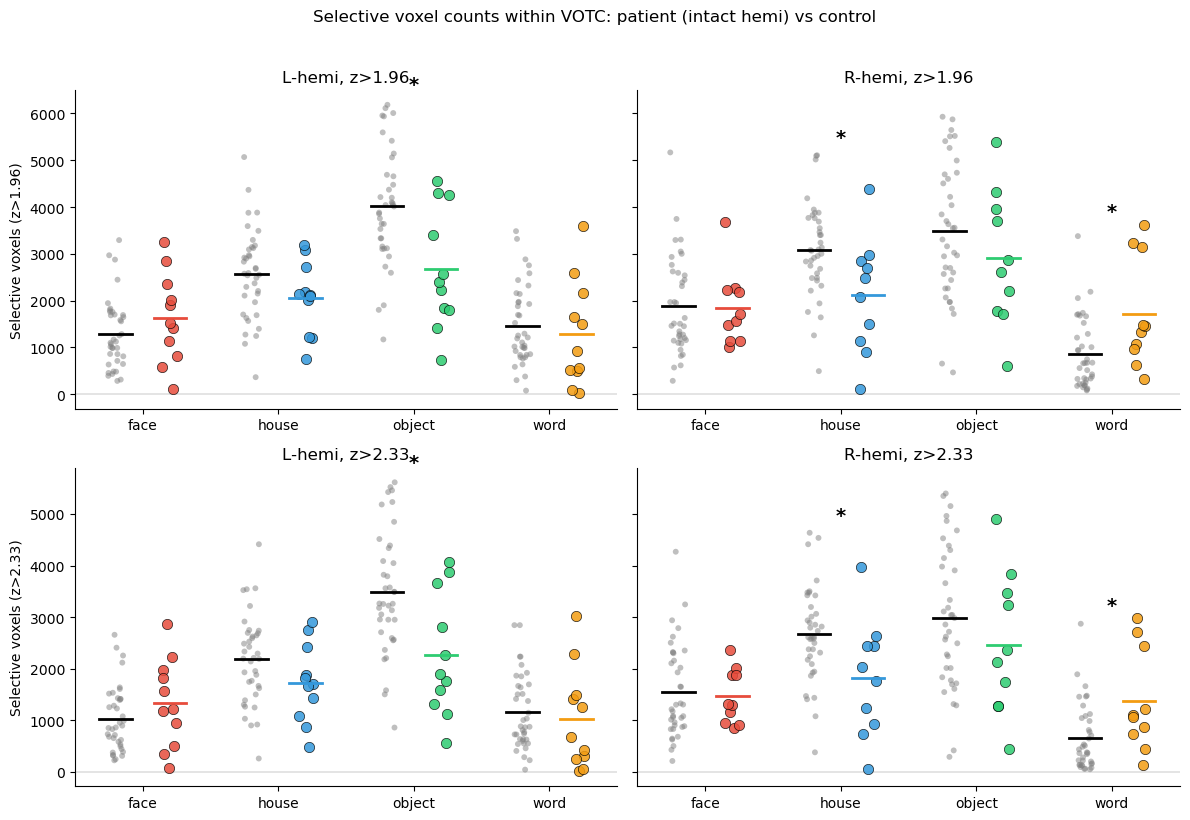

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
RNG = np.random.RandomState(42)

for row_i, t in enumerate([1.96, 2.33]):
    for col_i, h in enumerate(('l', 'r')):
        ax = axes[row_i, col_i]
        for xi, cat in enumerate(CATEGORIES):
            color = CAT_COLORS[cat] if 'CAT_COLORS' in dir() else CAT_COLOR[cat]
            ct = sv_df[(sv_df['group']=='control') & (sv_df['category']==cat) &
                       (sv_df['hemi']==h) & (sv_df['threshold']==t)]['n_selective'].values
            pt_sub = get_pt_for_hemi(sv_df, h)
            pt = pt_sub[(pt_sub['category']==cat) & (pt_sub['threshold']==t)]['n_selective'].values
            
            ax.scatter([xi - 0.2] * len(ct) + RNG.uniform(-0.06, 0.06, len(ct)),
                       ct, s=18, color='gray', alpha=0.5, edgecolors='none', zorder=2)
            ax.plot([xi - 0.32, xi - 0.08], [ct.mean()] * 2, color='black', lw=2, zorder=4)
            
            ax.scatter([xi + 0.2] * len(pt) + RNG.uniform(-0.06, 0.06, len(pt)),
                       pt, s=55, color=color, alpha=0.85,
                       edgecolors='black', linewidth=0.5, zorder=5)
            ax.plot([xi + 0.08, xi + 0.32], [pt.mean()] * 2, color=color, lw=2, zorder=6)
            
            r = sv_results_df[(sv_results_df['category']==cat) & (sv_results_df['hemi']==h) &
                              (sv_results_df['threshold']==t)]
            if len(r) and not np.isnan(r['p_perm'].iloc[0]) and r['p_perm'].iloc[0] < 0.05:
                y = max(ct.max() if len(ct) else 0, pt.max() if len(pt) else 0) * 1.05
                ax.text(xi, y, '*', ha='center', fontsize=14, fontweight='bold')
        
        ax.set_xticks(range(len(CATEGORIES)))
        ax.set_xticklabels(CATEGORIES)
        ax.set_title(f'{h.upper()}-hemi, z>{t}')
        if col_i == 0: ax.set_ylabel(f'Selective voxels (z>{t})')
        ax.axhline(0, color='gray', lw=0.3)

plt.suptitle('Selective voxel counts within VOTC: patient (intact hemi) vs control', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'selective_voxel_counts.png', dpi=200, bbox_inches='tight')
plt.show()

=== TFCE results: surviving voxels at p_FWE < .05 ===

     Cat  Hemi           Test  n_sig   max(1-p)
--------------------------------------------------
    face     l        ctrl>pt      0     0.2774
    face     l        pt>ctrl     20     0.9611
    face     r        ctrl>pt      0     0.7713
    face     r        pt>ctrl      0     0.5696
   house     l        ctrl>pt      0     0.3882
   house     l        pt>ctrl      0     0.1857
   house     r        ctrl>pt     97     0.9712
   house     r        pt>ctrl      0     0.0963
  object     l        ctrl>pt    268     0.9936
  object     l        pt>ctrl      0     0.2164
  object     r        ctrl>pt      0     0.8855
  object     r        pt>ctrl      0     0.5654
    word     l        ctrl>pt      0     0.8285
    word     l        pt>ctrl      0     0.3490
    word     r        ctrl>pt      0     0.6148
    word     r        pt>ctrl    385     0.9920

Plotting 4 tests with surviving voxels...


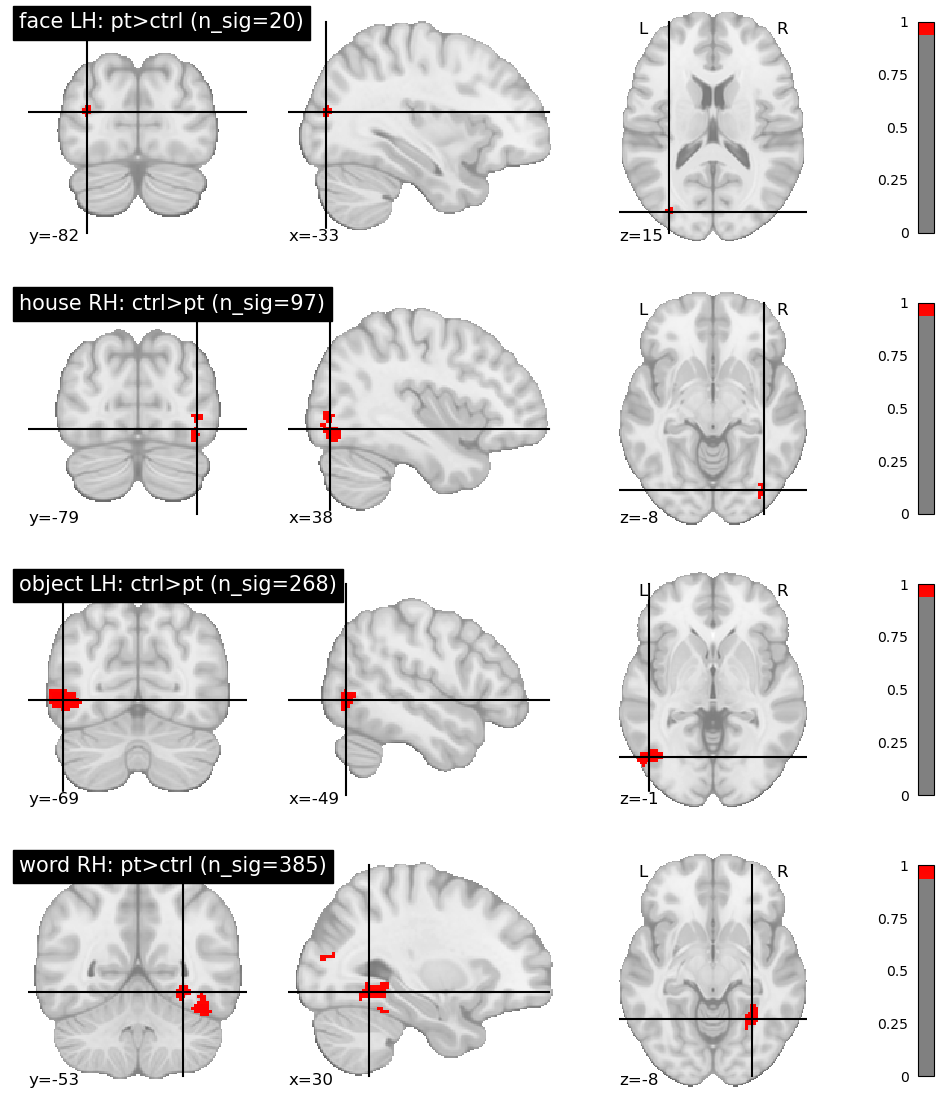

In [44]:
from nilearn import plotting, image
from pathlib import Path

TFCE_DIR = Path(processed_dir) / 'group_results' / 'tfce_votc'
FWE_THRESH = 0.95  # 1 - p_FWE; voxels > 0.95 are p<.05 FWE-corrected

# Summary table first
print('=== TFCE results: surviving voxels at p_FWE < .05 ===\n')
print(f'{"Cat":>8s} {"Hemi":>5s} {"Test":>14s} {"n_sig":>6s} {"max(1-p)":>10s}')
print('-' * 50)
sig_results = []
for cat in CATEGORIES:
    for h in ('l', 'r'):
        test_dir = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl'
        for tstat, label in [(1, 'ctrl>pt'), (2, 'pt>ctrl')]:
            f = test_dir / f'rand_tfce_corrp_tstat{tstat}.nii.gz'
            if not f.exists():
                print(f'{cat:>8s} {h:>5s} {label:>14s} {"missing":>16s}')
                continue
            data = nib.load(f).get_fdata()
            sig_mask = data > FWE_THRESH
            n_sig = int(sig_mask.sum())
            max_val = float(data.max())
            print(f'{cat:>8s} {h:>5s} {label:>14s} {n_sig:>6d} {max_val:>10.4f}')
            sig_results.append({'category': cat, 'hemi': h, 'test': label,
                                'file': f, 'n_sig': n_sig, 'max_1_minus_p': max_val})
sig_df = pd.DataFrame(sig_results)

# Plot only tests with surviving voxels
plotted = sig_df[sig_df['n_sig'] > 0]
if len(plotted) == 0:
    print('\nNo voxels survive FWE correction at p<.05 across any test.')
else:
    print(f'\nPlotting {len(plotted)} tests with surviving voxels...')
    fig, axes = plt.subplots(len(plotted), 1, figsize=(12, 3.5 * len(plotted)))
    if len(plotted) == 1: axes = [axes]
    
    for ax, (_, r) in zip(axes, plotted.iterrows()):
        title = f"{r['category']} {r['hemi'].upper()}H: {r['test']} (n_sig={r['n_sig']})"
        plotting.plot_stat_map(
            str(r['file']),
            threshold=FWE_THRESH,
            display_mode='ortho',
            cut_coords=None,
            colorbar=True,
            title=title,
            axes=ax,
            cmap='autumn_r',
            vmax=1.0,
        )
    plt.savefig(FIG_DIR / 'tfce_results.png', dpi=150, bbox_inches='tight')
    plt.show()

face pt>ctrl: 2 surf vertices


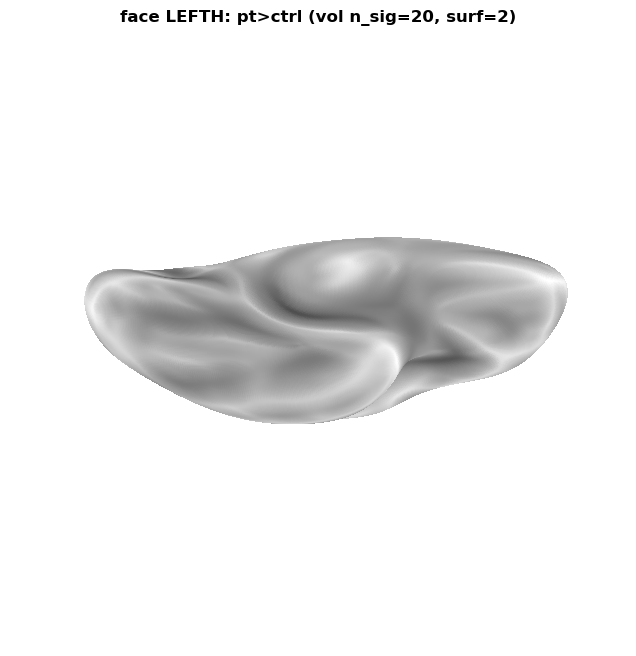

house ctrl>pt: 0 surf vertices


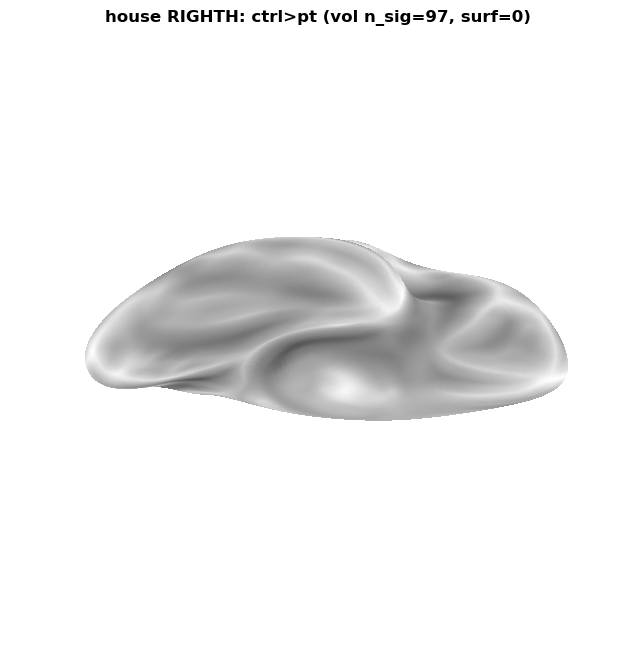

object ctrl>pt: 297 surf vertices


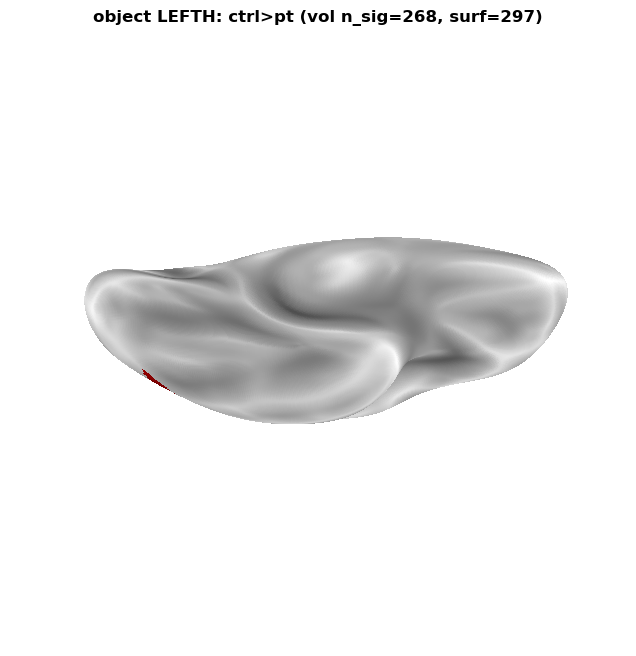

word pt>ctrl: 253 surf vertices


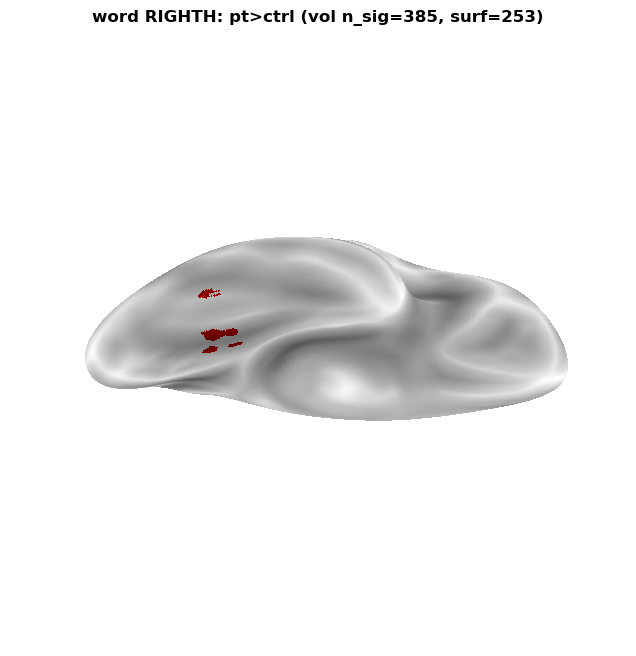

In [42]:
from nilearn import datasets as nl_datasets
from nilearn.plotting import plot_surf_roi
fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
from matplotlib.colors import ListedColormap
VOL_TO_SURF_RADIUS = 3.0

plotted = sig_df[sig_df['n_sig'] > 0].reset_index(drop=True)
FWE_THRESH = 0.95

for _, r in plotted.iterrows():
    vol_img = nib.load(str(r['file']))
    vol_data = vol_img.get_fdata()

    # Pick hemi from cluster centroid
    coords_xyz = np.argwhere(vol_data > FWE_THRESH)
    centroid_x = nib.affines.apply_affine(vol_img.affine, coords_xyz).mean(0)[0]
    hemi_full = 'right' if centroid_x > 0 else 'left'

    # Project on pial with line sampling (matches your working helper)
    surf_data = surface.vol_to_surf(
        vol_img, fsaverage[f'pial_{hemi_full}'],
        interpolation='linear',
        radius=VOL_TO_SURF_RADIUS,
        kind='line',
    )

    # Binarize for plot_surf_roi (matches your control/patient cells)
    roi = (surf_data > FWE_THRESH).astype(int)
    print(f"{r['category']} {r['test']}: {roi.sum()} surf vertices")

    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': '3d'})
    plot_surf_roi(
        fsaverage[f'infl_{hemi_full}'], roi_map=roi,
        hemi=hemi_full, view='ventral',
        cmap=ListedColormap(['#808080', '#cc0000']),
        vmin=0, vmax=1,
        bg_map=fsaverage[f'sulc_{hemi_full}'],
        bg_on_data=True, darkness=0.7, axes=ax,
    )
    ax.set_title(f"{r['category']} {hemi_full.upper()}H: {r['test']} "
                 f"(vol n_sig={r['n_sig']}, surf={int(roi.sum())})",
                 fontsize=12, fontweight='bold')
    plt.show()